# Best D4 Orbit-Reuploading Quantum Bottleneck for Model I

**Executed, self-contained architecture and paper report**

This notebook contains only the selected seed-2 hybrid quantum model used for three-class gravitational-lensing classification. It defines the exact model, strictly loads the frozen checkpoint, audits all parameters, replays hash-verified CUDA-Q inference and audits the D4 orbit, recomputes the sealed official-test metrics, and generates paper-ready figures.

**Selected result:** 98.4746% development-validation accuracy and **98.3667% official-test accuracy** on 15,000 held-out images. The official-test prediction bundle was generated in the prospectively sealed v3 pass; this notebook analyzes that immutable bundle and does not tune on the test set.

The quantum circuit in this notebook is explicitly built with `@cudaq.kernel` and the model's primary inference path calls CUDA-Q. PyTorch is used for the classical encoder/head and to store the frozen 88-value checkpoint tensor. Those values were originally optimized with a differentiable training simulator; this notebook does not mislabel that historical training as CUDA-Q training.

## Reproducibility contract

- Classes: `axion`, `cdm`, `no_sub`.
- Development split: 70,021 training and 17,504 validation images, stratified with seed 42.
- Official test: 15,000 balanced images, exactly 5,000 per class.
- Model selection used development validation only.
- Selected checkpoint: seed 2, best epoch 19.
- Checkpoint, predictions, and result JSON are checked against fixed SHA-256 digests before analysis.
- Representative images are selected deterministically from the development-validation split. Official-test pixels are not opened for figure selection.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import os
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import torch
from IPython.display import display, Markdown

torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.manual_seed(2)
np.random.seed(2)

DATA_ROOT = Path(os.environ.get("DEEPLENSE_DATA_ROOT", "/home/jovyan/data"))
SEALED_MEMBER = DATA_ROOT / "outputs/deeplense-quantum/d4-orqb/model-i/locked/d4-orqb-model-i-v3-20260711-seal/members/q2"
OFFICIAL = DATA_ROOT / "outputs/deeplense-quantum/d4-orqb/model-i/locked/d4-orqb-model-i-v3-20260711-official-test"
CACHE = DATA_ROOT / "cache/d4-orqb/model_i_96_v1"
CHECKPOINT = SEALED_MEMBER / "best.pt"
VALIDATION_SUMMARY = SEALED_MEMBER / "summary.json"
HISTORY = SEALED_MEMBER / "history.json"
TEST_PREDICTIONS = OFFICIAL / "predictions/q2.npz"
TEST_RESULT = OFFICIAL / "result.json"
FIGURE_DIR = DATA_ROOT / "outputs/deeplense-quantum-paper-best-q2/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_SHA256 = {
    CHECKPOINT: "9b6bb5bab038b086c7e6dd3b0448de9fa204e6138e28da8bb13deb9374f87007",
    TEST_PREDICTIONS: "1479ffe28b950320166f913ed8dd53b0d9dceb4626faf79444ea17f9e96ae691",
    TEST_RESULT: "86b0b1df9cf33a772719799dd0d7632e81312e837c0de39e0003fc4e8ca83340",
}

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing = [str(path) for path in EXPECTED_SHA256 if not path.is_file()]
assert not missing, f"Missing required artifacts: {missing}"
observed_hashes = {str(path): sha256(path) for path in EXPECTED_SHA256}
for path, expected in EXPECTED_SHA256.items():
    assert observed_hashes[str(path)] == expected, f"SHA-256 mismatch: {path}"

CLASS_NAMES = ("Axion", "CDM", "No substructure")
COLORS = ("#6A5ACD", "#E45756", "#2A9D8F")
mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "device": "cpu",
    "artifact_hashes_verified": len(EXPECTED_SHA256),
    "paper_figure_directory": str(FIGURE_DIR),
})

{'python': '3.11.11', 'torch': '2.5.1+cu124', 'device': 'cpu', 'artifact_hashes_verified': 3, 'paper_figure_directory': '/home/jovyan/data/outputs/deeplense-quantum-paper-best-q2/figures'}


## Exact selected architecture

1. Each 96×96 intensity image is converted into eight fixed physics-informed maps: normalized intensity, log intensity, gradient magnitude, Laplacian magnitude, difference of local averages, radial gradient, tangential gradient, and a stabilized mixed derivative.
2. All eight elements of the dihedral group D4 are applied to the image. One shared MobileNet-style MBConv feature extractor produces a 128-dimensional descriptor for every orbit view.
3. A shared linear orbit projection maps each descriptor to two angle fields for each of four quantum heads, giving a tensor of shape `batch × 4 × 2 × 8`.
4. Each head is an eight-qubit CUDA-Q circuit with two data reuploads. Every reupload performs dense RY/RZ data encoding, tied local RX/RY/RZ rotations, and symmetry-tied XX/ZZ interactions over complete D4 Cayley-edge orbits.
5. Local X/Z and pair XX/ZZ expectations are orbit-reduced into 12 invariant values per head, producing a 48-dimensional D4-invariant quantum bottleneck.
6. A compact prediction head maps the 48 invariants to three class logits.

The next cell is the literal CUDA-Q circuit and analytic readout backend; the following cell is the checkpoint-compatible hybrid model. It contains only this selected path and preserves every checkpoint key exactly.

In [2]:
"""Primary CUDA-Q circuit and analytic invariant backend.

This cell contains the actual decorated quantum kernel used for inference.
It deliberately has no PyTorch dependency and can be executed directly in
the pinned NVIDIA CUDA-Q container.
"""

from __future__ import annotations

import importlib.util
from typing import Any

import numpy as np

CUDAQ_HEADS = 4
CUDAQ_REUPLOADS = 2
CUDAQ_QUBITS = 8
CUDAQ_PARAMETERS_PER_LAYER = 11
CUDAQ_INVARIANTS_PER_HEAD = 12
R_EDGES = (
    (0, 1), (0, 3), (1, 2), (2, 3),
    (4, 5), (4, 7), (5, 6), (6, 7),
)
R2_EDGES = ((0, 2), (1, 3), (4, 6), (5, 7))
S_EDGES = ((0, 4), (1, 7), (2, 6), (3, 5))
PAIR_FAMILIES = (R_EDGES, R2_EDGES, S_EDGES)

CUDAQ_AVAILABLE = importlib.util.find_spec("cudaq") is not None
if CUDAQ_AVAILABLE:
    import cudaq

    @cudaq.kernel
    def d4_orqb_q2_head(features: list[float], parameters: list[float]):
        qubits = cudaq.qvector(8)
        ry(parameters[0] * features[0] + parameters[1], qubits[7])
        rz(parameters[2] * features[8] + parameters[3], qubits[7])
        ry(parameters[0] * features[1] + parameters[1], qubits[6])
        rz(parameters[2] * features[9] + parameters[3], qubits[6])
        ry(parameters[0] * features[2] + parameters[1], qubits[5])
        rz(parameters[2] * features[10] + parameters[3], qubits[5])
        ry(parameters[0] * features[3] + parameters[1], qubits[4])
        rz(parameters[2] * features[11] + parameters[3], qubits[4])
        ry(parameters[0] * features[4] + parameters[1], qubits[3])
        rz(parameters[2] * features[12] + parameters[3], qubits[3])
        ry(parameters[0] * features[5] + parameters[1], qubits[2])
        rz(parameters[2] * features[13] + parameters[3], qubits[2])
        ry(parameters[0] * features[6] + parameters[1], qubits[1])
        rz(parameters[2] * features[14] + parameters[3], qubits[1])
        ry(parameters[0] * features[7] + parameters[1], qubits[0])
        rz(parameters[2] * features[15] + parameters[3], qubits[0])
        rx(parameters[4], qubits[7])
        ry(parameters[5], qubits[7])
        rz(parameters[6], qubits[7])
        rx(parameters[4], qubits[6])
        ry(parameters[5], qubits[6])
        rz(parameters[6], qubits[6])
        rx(parameters[4], qubits[5])
        ry(parameters[5], qubits[5])
        rz(parameters[6], qubits[5])
        rx(parameters[4], qubits[4])
        ry(parameters[5], qubits[4])
        rz(parameters[6], qubits[4])
        rx(parameters[4], qubits[3])
        ry(parameters[5], qubits[3])
        rz(parameters[6], qubits[3])
        rx(parameters[4], qubits[2])
        ry(parameters[5], qubits[2])
        rz(parameters[6], qubits[2])
        rx(parameters[4], qubits[1])
        ry(parameters[5], qubits[1])
        rz(parameters[6], qubits[1])
        rx(parameters[4], qubits[0])
        ry(parameters[5], qubits[0])
        rz(parameters[6], qubits[0])
        x.ctrl(qubits[7], qubits[6])
        rz(parameters[7], qubits[6])
        x.ctrl(qubits[7], qubits[6])
        x.ctrl(qubits[7], qubits[4])
        rz(parameters[7], qubits[4])
        x.ctrl(qubits[7], qubits[4])
        x.ctrl(qubits[6], qubits[5])
        rz(parameters[7], qubits[5])
        x.ctrl(qubits[6], qubits[5])
        x.ctrl(qubits[5], qubits[4])
        rz(parameters[7], qubits[4])
        x.ctrl(qubits[5], qubits[4])
        x.ctrl(qubits[3], qubits[2])
        rz(parameters[7], qubits[2])
        x.ctrl(qubits[3], qubits[2])
        x.ctrl(qubits[3], qubits[0])
        rz(parameters[7], qubits[0])
        x.ctrl(qubits[3], qubits[0])
        x.ctrl(qubits[2], qubits[1])
        rz(parameters[7], qubits[1])
        x.ctrl(qubits[2], qubits[1])
        x.ctrl(qubits[1], qubits[0])
        rz(parameters[7], qubits[0])
        x.ctrl(qubits[1], qubits[0])
        x.ctrl(qubits[7], qubits[3])
        rz(parameters[8], qubits[3])
        x.ctrl(qubits[7], qubits[3])
        x.ctrl(qubits[6], qubits[0])
        rz(parameters[8], qubits[0])
        x.ctrl(qubits[6], qubits[0])
        x.ctrl(qubits[5], qubits[1])
        rz(parameters[8], qubits[1])
        x.ctrl(qubits[5], qubits[1])
        x.ctrl(qubits[4], qubits[2])
        rz(parameters[8], qubits[2])
        x.ctrl(qubits[4], qubits[2])
        h(qubits[7])
        h(qubits[6])
        x.ctrl(qubits[7], qubits[6])
        rz(parameters[9], qubits[6])
        x.ctrl(qubits[7], qubits[6])
        h(qubits[7])
        h(qubits[6])
        h(qubits[7])
        h(qubits[4])
        x.ctrl(qubits[7], qubits[4])
        rz(parameters[9], qubits[4])
        x.ctrl(qubits[7], qubits[4])
        h(qubits[7])
        h(qubits[4])
        h(qubits[6])
        h(qubits[5])
        x.ctrl(qubits[6], qubits[5])
        rz(parameters[9], qubits[5])
        x.ctrl(qubits[6], qubits[5])
        h(qubits[6])
        h(qubits[5])
        h(qubits[5])
        h(qubits[4])
        x.ctrl(qubits[5], qubits[4])
        rz(parameters[9], qubits[4])
        x.ctrl(qubits[5], qubits[4])
        h(qubits[5])
        h(qubits[4])
        h(qubits[3])
        h(qubits[2])
        x.ctrl(qubits[3], qubits[2])
        rz(parameters[9], qubits[2])
        x.ctrl(qubits[3], qubits[2])
        h(qubits[3])
        h(qubits[2])
        h(qubits[3])
        h(qubits[0])
        x.ctrl(qubits[3], qubits[0])
        rz(parameters[9], qubits[0])
        x.ctrl(qubits[3], qubits[0])
        h(qubits[3])
        h(qubits[0])
        h(qubits[2])
        h(qubits[1])
        x.ctrl(qubits[2], qubits[1])
        rz(parameters[9], qubits[1])
        x.ctrl(qubits[2], qubits[1])
        h(qubits[2])
        h(qubits[1])
        h(qubits[1])
        h(qubits[0])
        x.ctrl(qubits[1], qubits[0])
        rz(parameters[9], qubits[0])
        x.ctrl(qubits[1], qubits[0])
        h(qubits[1])
        h(qubits[0])
        h(qubits[7])
        h(qubits[3])
        x.ctrl(qubits[7], qubits[3])
        rz(parameters[10], qubits[3])
        x.ctrl(qubits[7], qubits[3])
        h(qubits[7])
        h(qubits[3])
        h(qubits[6])
        h(qubits[0])
        x.ctrl(qubits[6], qubits[0])
        rz(parameters[10], qubits[0])
        x.ctrl(qubits[6], qubits[0])
        h(qubits[6])
        h(qubits[0])
        h(qubits[5])
        h(qubits[1])
        x.ctrl(qubits[5], qubits[1])
        rz(parameters[10], qubits[1])
        x.ctrl(qubits[5], qubits[1])
        h(qubits[5])
        h(qubits[1])
        h(qubits[4])
        h(qubits[2])
        x.ctrl(qubits[4], qubits[2])
        rz(parameters[10], qubits[2])
        x.ctrl(qubits[4], qubits[2])
        h(qubits[4])
        h(qubits[2])
        ry(parameters[11] * features[0] + parameters[12], qubits[7])
        rz(parameters[13] * features[8] + parameters[14], qubits[7])
        ry(parameters[11] * features[1] + parameters[12], qubits[6])
        rz(parameters[13] * features[9] + parameters[14], qubits[6])
        ry(parameters[11] * features[2] + parameters[12], qubits[5])
        rz(parameters[13] * features[10] + parameters[14], qubits[5])
        ry(parameters[11] * features[3] + parameters[12], qubits[4])
        rz(parameters[13] * features[11] + parameters[14], qubits[4])
        ry(parameters[11] * features[4] + parameters[12], qubits[3])
        rz(parameters[13] * features[12] + parameters[14], qubits[3])
        ry(parameters[11] * features[5] + parameters[12], qubits[2])
        rz(parameters[13] * features[13] + parameters[14], qubits[2])
        ry(parameters[11] * features[6] + parameters[12], qubits[1])
        rz(parameters[13] * features[14] + parameters[14], qubits[1])
        ry(parameters[11] * features[7] + parameters[12], qubits[0])
        rz(parameters[13] * features[15] + parameters[14], qubits[0])
        rx(parameters[15], qubits[7])
        ry(parameters[16], qubits[7])
        rz(parameters[17], qubits[7])
        rx(parameters[15], qubits[6])
        ry(parameters[16], qubits[6])
        rz(parameters[17], qubits[6])
        rx(parameters[15], qubits[5])
        ry(parameters[16], qubits[5])
        rz(parameters[17], qubits[5])
        rx(parameters[15], qubits[4])
        ry(parameters[16], qubits[4])
        rz(parameters[17], qubits[4])
        rx(parameters[15], qubits[3])
        ry(parameters[16], qubits[3])
        rz(parameters[17], qubits[3])
        rx(parameters[15], qubits[2])
        ry(parameters[16], qubits[2])
        rz(parameters[17], qubits[2])
        rx(parameters[15], qubits[1])
        ry(parameters[16], qubits[1])
        rz(parameters[17], qubits[1])
        rx(parameters[15], qubits[0])
        ry(parameters[16], qubits[0])
        rz(parameters[17], qubits[0])
        x.ctrl(qubits[7], qubits[6])
        rz(parameters[18], qubits[6])
        x.ctrl(qubits[7], qubits[6])
        x.ctrl(qubits[7], qubits[4])
        rz(parameters[18], qubits[4])
        x.ctrl(qubits[7], qubits[4])
        x.ctrl(qubits[6], qubits[5])
        rz(parameters[18], qubits[5])
        x.ctrl(qubits[6], qubits[5])
        x.ctrl(qubits[5], qubits[4])
        rz(parameters[18], qubits[4])
        x.ctrl(qubits[5], qubits[4])
        x.ctrl(qubits[3], qubits[2])
        rz(parameters[18], qubits[2])
        x.ctrl(qubits[3], qubits[2])
        x.ctrl(qubits[3], qubits[0])
        rz(parameters[18], qubits[0])
        x.ctrl(qubits[3], qubits[0])
        x.ctrl(qubits[2], qubits[1])
        rz(parameters[18], qubits[1])
        x.ctrl(qubits[2], qubits[1])
        x.ctrl(qubits[1], qubits[0])
        rz(parameters[18], qubits[0])
        x.ctrl(qubits[1], qubits[0])
        x.ctrl(qubits[7], qubits[3])
        rz(parameters[19], qubits[3])
        x.ctrl(qubits[7], qubits[3])
        x.ctrl(qubits[6], qubits[0])
        rz(parameters[19], qubits[0])
        x.ctrl(qubits[6], qubits[0])
        x.ctrl(qubits[5], qubits[1])
        rz(parameters[19], qubits[1])
        x.ctrl(qubits[5], qubits[1])
        x.ctrl(qubits[4], qubits[2])
        rz(parameters[19], qubits[2])
        x.ctrl(qubits[4], qubits[2])
        h(qubits[7])
        h(qubits[6])
        x.ctrl(qubits[7], qubits[6])
        rz(parameters[20], qubits[6])
        x.ctrl(qubits[7], qubits[6])
        h(qubits[7])
        h(qubits[6])
        h(qubits[7])
        h(qubits[4])
        x.ctrl(qubits[7], qubits[4])
        rz(parameters[20], qubits[4])
        x.ctrl(qubits[7], qubits[4])
        h(qubits[7])
        h(qubits[4])
        h(qubits[6])
        h(qubits[5])
        x.ctrl(qubits[6], qubits[5])
        rz(parameters[20], qubits[5])
        x.ctrl(qubits[6], qubits[5])
        h(qubits[6])
        h(qubits[5])
        h(qubits[5])
        h(qubits[4])
        x.ctrl(qubits[5], qubits[4])
        rz(parameters[20], qubits[4])
        x.ctrl(qubits[5], qubits[4])
        h(qubits[5])
        h(qubits[4])
        h(qubits[3])
        h(qubits[2])
        x.ctrl(qubits[3], qubits[2])
        rz(parameters[20], qubits[2])
        x.ctrl(qubits[3], qubits[2])
        h(qubits[3])
        h(qubits[2])
        h(qubits[3])
        h(qubits[0])
        x.ctrl(qubits[3], qubits[0])
        rz(parameters[20], qubits[0])
        x.ctrl(qubits[3], qubits[0])
        h(qubits[3])
        h(qubits[0])
        h(qubits[2])
        h(qubits[1])
        x.ctrl(qubits[2], qubits[1])
        rz(parameters[20], qubits[1])
        x.ctrl(qubits[2], qubits[1])
        h(qubits[2])
        h(qubits[1])
        h(qubits[1])
        h(qubits[0])
        x.ctrl(qubits[1], qubits[0])
        rz(parameters[20], qubits[0])
        x.ctrl(qubits[1], qubits[0])
        h(qubits[1])
        h(qubits[0])
        h(qubits[7])
        h(qubits[3])
        x.ctrl(qubits[7], qubits[3])
        rz(parameters[21], qubits[3])
        x.ctrl(qubits[7], qubits[3])
        h(qubits[7])
        h(qubits[3])
        h(qubits[6])
        h(qubits[0])
        x.ctrl(qubits[6], qubits[0])
        rz(parameters[21], qubits[0])
        x.ctrl(qubits[6], qubits[0])
        h(qubits[6])
        h(qubits[0])
        h(qubits[5])
        h(qubits[1])
        x.ctrl(qubits[5], qubits[1])
        rz(parameters[21], qubits[1])
        x.ctrl(qubits[5], qubits[1])
        h(qubits[5])
        h(qubits[1])
        h(qubits[4])
        h(qubits[2])
        x.ctrl(qubits[4], qubits[2])
        rz(parameters[21], qubits[2])
        x.ctrl(qubits[4], qubits[2])
        h(qubits[4])
        h(qubits[2])
else:
    cudaq = None
    d4_orqb_q2_head = None


def cudaq_primitive_expectations(state: np.ndarray) -> np.ndarray:
    """Compute ordered Z/X/ZZ/XX expectations from one CUDA-Q state."""
    state = np.asarray(state, dtype=np.complex128).reshape(-1)
    if state.shape != (1 << CUDAQ_QUBITS,):
        raise ValueError(f"Expected 256 amplitudes, got {state.shape}")
    norm = float(np.vdot(state, state).real)
    if not np.isclose(norm, 1.0, atol=2e-5):
        raise ValueError(f"Invalid CUDA-Q state norm {norm}")
    basis = np.arange(1 << CUDAQ_QUBITS, dtype=np.int64)
    probabilities = np.square(np.abs(state))
    z_values, x_values = [], []
    for logical in range(CUDAQ_QUBITS):
        mask = 1 << (CUDAQ_QUBITS - logical - 1)
        signs = np.where((basis & mask) != 0, -1.0, 1.0)
        z_values.append(float(probabilities @ signs))
        x_values.append(float(np.vdot(state, state[basis ^ mask]).real))
    values = z_values + x_values
    for pauli in ("z", "x"):
        for edges in PAIR_FAMILIES:
            for logical_a, logical_b in edges:
                mask_a = 1 << (CUDAQ_QUBITS - logical_a - 1)
                mask_b = 1 << (CUDAQ_QUBITS - logical_b - 1)
                if pauli == "z":
                    signs = np.where((basis & mask_a) != 0, -1.0, 1.0)
                    signs *= np.where((basis & mask_b) != 0, -1.0, 1.0)
                    values.append(float(probabilities @ signs))
                else:
                    values.append(
                        float(np.vdot(state, state[basis ^ mask_a ^ mask_b]).real)
                    )
    output = np.asarray(values, dtype=np.float64)
    if output.shape != (48,):
        raise AssertionError(output.shape)
    return output


def cudaq_invariants_from_expectations(values: np.ndarray) -> np.ndarray:
    """Reduce 48 primitive expectations to the exact 12 head invariants."""
    values = np.asarray(values, dtype=np.float64)
    cursor = 0
    z_values = values[cursor:cursor + 8]; cursor += 8
    x_values = values[cursor:cursor + 8]; cursor += 8
    zz_values, xx_values = [], []
    for destination in (zz_values, xx_values):
        for edges in PAIR_FAMILIES:
            destination.append(values[cursor:cursor + len(edges)])
            cursor += len(edges)
    z_mean, x_mean = z_values.mean(), x_values.mean()
    r_z_product = np.asarray([z_values[a] * z_values[b] for a, b in R_EDGES])
    r_x_product = np.asarray([x_values[a] * x_values[b] for a, b in R_EDGES])
    output = np.asarray([
        z_mean,
        np.square(z_values).mean() - z_mean**2,
        x_mean,
        np.square(x_values).mean() - x_mean**2,
        *(family.mean() for family in zz_values),
        *(family.mean() for family in xx_values),
        (zz_values[0] - r_z_product).mean(),
        (xx_values[0] - r_x_product).mean(),
    ], dtype=np.float64)
    if output.shape != (CUDAQ_INVARIANTS_PER_HEAD,):
        raise AssertionError(output.shape)
    return output


class CudaQD4OrbitBackend:
    """CUDA-Q execution of four independent selected q2 head circuits."""

    def __init__(self, target: str = "nvidia") -> None:
        self.target = target
        self.initialized = False

    def initialize(self) -> None:
        if self.initialized:
            return
        if not CUDAQ_AVAILABLE or d4_orqb_q2_head is None:
            raise RuntimeError(
                "CUDA-Q is not installed in this kernel. Use the pinned NVIDIA "
                "CUDA-Q container to launch quantum inference."
            )
        if self.target != "nvidia":
            raise ValueError("This analytic backend was audited for target='nvidia'")
        cudaq.set_target(self.target)
        self.initialized = True

    def _head(self, features: np.ndarray, parameters: np.ndarray) -> np.ndarray:
        self.initialize()
        state = cudaq.get_state(
            d4_orqb_q2_head,
            np.asarray(features, dtype=np.float64).reshape(16).tolist(),
            np.asarray(parameters, dtype=np.float64).reshape(22).tolist(),
        )
        state_array = state.to_numpy() if hasattr(state, "to_numpy") else np.asarray(state)
        return cudaq_invariants_from_expectations(
            cudaq_primitive_expectations(state_array)
        )

    def __call__(self, angles: np.ndarray, parameters: np.ndarray) -> np.ndarray:
        angles = np.asarray(angles)
        parameters = np.asarray(parameters)
        if angles.ndim != 4 or angles.shape[1:] != (4, 2, 8):
            raise ValueError(f"Expected angles (B,4,2,8), got {angles.shape}")
        if parameters.shape != (4, 2, 11):
            raise ValueError(f"Expected parameters (4,2,11), got {parameters.shape}")
        output = np.empty((len(angles), 48), dtype=np.float32)
        for sample in range(len(angles)):
            for head in range(CUDAQ_HEADS):
                start = head * CUDAQ_INVARIANTS_PER_HEAD
                output[sample, start:start + CUDAQ_INVARIANTS_PER_HEAD] = self._head(
                    angles[sample, head], parameters[head]
                )
        return output


print({
    "primary_quantum_implementation": "CUDA-Q @cudaq.kernel",
    "cudaq_available_in_this_notebook_kernel": CUDAQ_AVAILABLE,
    "heads": CUDAQ_HEADS,
    "qubits_per_head": CUDAQ_QUBITS,
    "reuploads": CUDAQ_REUPLOADS,
    "parameters": CUDAQ_HEADS * CUDAQ_REUPLOADS * CUDAQ_PARAMETERS_PER_LAYER,
})


{'primary_quantum_implementation': 'CUDA-Q @cudaq.kernel', 'cudaq_available_in_this_notebook_kernel': False, 'heads': 4, 'qubits_per_head': 8, 'reuploads': 2, 'parameters': 88}


In [3]:
"""Checkpoint-compatible hybrid definition with a CUDA-Q quantum core.

The classical image path is PyTorch. Quantum state preparation, gates, and
statevector execution are delegated to the direct CUDA-Q kernel defined above.
The parameter-only core preserves every checkpoint key exactly.
"""

from __future__ import annotations

import math
from pathlib import Path
import sys
from typing import Any

import numpy as np
import torch
import torch.nn.functional as F
from torch import nn


DEFAULT_CHECKPOINT = Path(
    "/home/jovyan/data/outputs/deeplense-quantum/"
    "d4-orqb/model-i/fixed-backbone-replication/seed-2/quantum/best.pt"
)
CLASS_NAMES = ("axion", "cdm", "no_sub")

R_EDGES: tuple[tuple[int, int], ...] = (
    (0, 1),
    (0, 3),
    (1, 2),
    (2, 3),
    (4, 5),
    (4, 7),
    (5, 6),
    (6, 7),
)
R2_EDGES: tuple[tuple[int, int], ...] = ((0, 2), (1, 3), (4, 6), (5, 7))
S_EDGES: tuple[tuple[int, int], ...] = ((0, 4), (1, 7), (2, 6), (3, 5))


def norm2d(channels: int) -> nn.GroupNorm:
    groups = min(8, channels)
    while channels % groups:
        groups -= 1
    return nn.GroupNorm(groups, channels)


def d4_transform(
    images: torch.Tensor, rotation: int, reflected: int
) -> torch.Tensor:
    if reflected:
        images = torch.flip(images, dims=(-1,))
    return torch.rot90(images, rotation, dims=(-2, -1))


def d4_views(images: torch.Tensor) -> torch.Tensor:
    return torch.stack(
        [d4_transform(images, rotation, reflected) for reflected in (0, 1) for rotation in range(4)],
        dim=1,
    )


class PhysicsChannelBank(nn.Module):
    """The exact zero-parameter eight-channel base physics bank."""

    def __init__(
        self,
        log_gain: float = 20.0,
        epsilon: float = 1e-3,
        reference_pixels: int = 96,
    ) -> None:
        super().__init__()
        self.log_gain = float(log_gain)
        self.epsilon = float(epsilon)
        self.reference_pixels = int(reference_pixels)
        self.output_channels = 8
        sobel_x = torch.tensor(
            [[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]]
        ) / 8.0
        sobel_y = sobel_x.transpose(0, 1).contiguous()
        laplacian = torch.tensor(
            [[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]]
        )
        self.register_buffer(
            "sobel_x", sobel_x.view(1, 1, 3, 3), persistent=False
        )
        self.register_buffer(
            "sobel_y", sobel_y.view(1, 1, 3, 3), persistent=False
        )
        self.register_buffer(
            "laplacian", laplacian.view(1, 1, 3, 3), persistent=False
        )

    @staticmethod
    def _conv_reflect(images: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
        return F.conv2d(F.pad(images, (1, 1, 1, 1), mode="reflect"), kernel)

    @staticmethod
    def _avg_reflect(images: torch.Tensor, kernel_size: int) -> torch.Tensor:
        pad = kernel_size // 2
        return F.avg_pool2d(
            F.pad(images, (pad, pad, pad, pad), mode="reflect"),
            kernel_size=kernel_size,
            stride=1,
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        images = torch.nan_to_num(
            images.float(), nan=0.0, posinf=0.0, neginf=0.0
        ).clamp_min(0.0)
        scale = images.amax(dim=(-2, -1), keepdim=True).clamp_min(1e-6)
        images = (images / scale).clamp(0.0, 1.0)
        log_intensity = torch.log1p(self.log_gain * images) / math.log1p(
            self.log_gain
        )

        gradient_x = self._conv_reflect(log_intensity, self.sobel_x)
        gradient_y = self._conv_reflect(log_intensity, self.sobel_y)
        pixel_scale = float(images.shape[-1]) / self.reference_pixels
        gradient = torch.sqrt(
            gradient_x.square() + gradient_y.square() + 1e-8
        ) * pixel_scale
        laplacian = (
            self._conv_reflect(log_intensity, self.laplacian).abs()
            * pixel_scale**2
        )
        small_kernel = max(3, int(round(3 * pixel_scale)) | 1)
        large_kernel = max(
            small_kernel + 2, int(round(9 * pixel_scale)) | 1
        )
        difference_of_averages = (
            self._avg_reflect(log_intensity, small_kernel)
            - self._avg_reflect(log_intensity, large_kernel)
        ).abs()

        height, width = images.shape[-2:]
        yy = torch.linspace(
            -1.0, 1.0, height, device=images.device, dtype=images.dtype
        )
        xx = torch.linspace(
            -1.0, 1.0, width, device=images.device, dtype=images.dtype
        )
        grid_y, grid_x = torch.meshgrid(yy, xx, indexing="ij")
        radius = torch.sqrt(grid_x.square() + grid_y.square()).clamp_min(1e-4)
        unit_x = (grid_x / radius).view(1, 1, height, width)
        unit_y = (grid_y / radius).view(1, 1, height, width)
        radial = (
            gradient_x * unit_x + gradient_y * unit_y
        ).abs() * pixel_scale
        tangential = (
            -gradient_x * unit_y + gradient_y * unit_x
        ).abs() * pixel_scale

        log_ratio_squared = torch.log(
            (1.0 + self.epsilon) / (images + self.epsilon)
        ).square()
        mixed = self._conv_reflect(
            self._conv_reflect(log_ratio_squared, self.sobel_x), self.sobel_y
        ).abs() * pixel_scale**2
        return torch.cat(
            (
                images,
                log_intensity,
                torch.tanh(2.0 * gradient),
                torch.tanh(laplacian),
                torch.tanh(4.0 * difference_of_averages),
                torch.tanh(2.0 * radial),
                torch.tanh(2.0 * tangential),
                torch.tanh(mixed),
            ),
            dim=1,
        )


class SqueezeExcite(nn.Module):
    def __init__(self, channels: int, reduction: int = 4) -> None:
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Hardsigmoid(inplace=True),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return features * self.net(features)


class MBConv(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        expand: int,
        stride: int,
        kernel_size: int = 5,
    ) -> None:
        super().__init__()
        hidden = in_channels * expand
        layers: list[nn.Module] = []
        if hidden != in_channels:
            layers.extend(
                (
                    nn.Conv2d(in_channels, hidden, 1, bias=False),
                    norm2d(hidden),
                    nn.SiLU(inplace=True),
                )
            )
        layers.extend(
            (
                nn.Conv2d(
                    hidden,
                    hidden,
                    kernel_size,
                    stride=stride,
                    padding=kernel_size // 2,
                    groups=hidden,
                    bias=False,
                ),
                norm2d(hidden),
                nn.SiLU(inplace=True),
                SqueezeExcite(hidden),
                nn.Conv2d(hidden, out_channels, 1, bias=False),
                norm2d(out_channels),
            )
        )
        self.block = nn.Sequential(*layers)
        self.use_residual = stride == 1 and in_channels == out_channels

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        output = self.block(features)
        return features + output if self.use_residual else output


class TinyOrbitEncoder(nn.Module):
    """The exact tiny encoder topology and checkpoint module names."""

    output_dim = 128

    def __init__(self, input_channels: int = 8) -> None:
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(
                input_channels, 16, 5, stride=2, padding=2, bias=False
            ),
            norm2d(16),
            nn.SiLU(inplace=True),
        )
        specifications = (
            (16, 24, 2, 2),
            (24, 24, 2, 1),
            (24, 40, 3, 2),
            (40, 40, 3, 1),
            (40, 64, 3, 2),
            (64, 64, 3, 1),
            (64, 96, 3, 2),
            (96, 96, 2, 1),
        )
        self.blocks = nn.Sequential(
            *(
                MBConv(in_channels, out_channels, expand, stride)
                for in_channels, out_channels, expand, stride in specifications
            )
        )
        self.final = nn.Sequential(
            nn.Conv2d(96, self.output_dim, 1, bias=False),
            norm2d(self.output_dim),
            nn.SiLU(inplace=True),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        features = self.stem(features)
        features = self.blocks(features)
        features = self.final(features)
        return features.mean(dim=(-2, -1))


class D4OrbitCudaQCore(nn.Module):
    """Checkpoint-compatible CUDA-Q core; PyTorch stores only the 88 weights."""

    parameters_per_layer = 11
    invariants_per_head = 12

    def __init__(self, target: str = "nvidia") -> None:
        super().__init__()
        self.heads = 4
        self.reuploads = 2
        self.n_qubits = 8
        parameters = torch.zeros(
            self.heads, self.reuploads, self.parameters_per_layer
        )
        parameters[..., 0] = 1.0
        parameters[..., 2] = 1.0
        parameters[..., 4:] = 0.02 * torch.randn_like(parameters[..., 4:])
        # This tensor preserves checkpoint key ``core.params``. Gate execution
        # is performed by CUDA-Q, not by PyTorch tensor state evolution.
        self.params = nn.Parameter(parameters)
        self.target = target
        self._backend: CudaQD4OrbitBackend | None = None

    @property
    def output_dim(self) -> int:
        return self.heads * self.invariants_per_head

    def forward(
        self, orbit_features: torch.Tensor, return_equivariant: bool = False
    ) -> torch.Tensor | tuple[torch.Tensor, None]:
        expected_shape = (self.heads, 2, self.n_qubits)
        if orbit_features.ndim != 4 or orbit_features.shape[1:] != expected_shape:
            raise ValueError(
                f"Expected (B,{self.heads},2,{self.n_qubits}), "
                f"got {tuple(orbit_features.shape)}"
            )
        if self.training:
            raise RuntimeError(
                "This frozen notebook uses CUDA-Q for inference. The existing "
                "checkpoint was originally optimized with a differentiable "
                "training simulator; CUDA-Q retraining was not performed."
            )
        if self._backend is None:
            self._backend = CudaQD4OrbitBackend(self.target)
        values = self._backend(
            np.asarray(orbit_features.detach().float().cpu()),
            np.asarray(self.params.detach().float().cpu()),
        )
        invariants = torch.from_numpy(values).to(
            device=orbit_features.device, dtype=torch.float32
        )
        return (invariants, None) if return_equivariant else invariants


class BestD4ORQB(nn.Module):
    """Exact 245,221-parameter seed-2 base/tiny D4-ORQB architecture."""

    def __init__(self) -> None:
        super().__init__()
        self.physics = PhysicsChannelBank()
        self.encoder = TinyOrbitEncoder(input_channels=8)
        self.orbit_projection = nn.Linear(128, 8)
        self.core = D4OrbitCudaQCore(target="nvidia")
        self.head = nn.Sequential(
            nn.LayerNorm(48),
            nn.Linear(48, 32),
            nn.SiLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(32, 3),
        )

    @property
    def parameter_count(self) -> int:
        return sum(parameter.numel() for parameter in self.parameters())

    def orbit_encode(
        self, images: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        views = d4_views(images)
        batch, group, channels, height, width = views.shape
        flattened_views = views.reshape(
            batch * group, channels, height, width
        )
        physics = self.physics(flattened_views)
        encoded_flat = self.encoder(physics)
        encoded = encoded_flat.reshape(batch, group, 128)
        projected = self.orbit_projection(encoded_flat)
        projected = projected.reshape(batch, group, 4, 2).permute(0, 2, 3, 1)
        angles = math.pi * torch.tanh(projected)
        return encoded, angles

    def forward(
        self, images: torch.Tensor, return_aux: bool = False
    ) -> torch.Tensor | tuple[torch.Tensor, dict[str, Any]]:
        encoded, angles = self.orbit_encode(images)
        if return_aux:
            invariants, equivariant = self.core(
                angles, return_equivariant=True
            )
        else:
            invariants = self.core(angles)
            equivariant = None
        logits = self.head(invariants)
        if not return_aux:
            return logits
        return logits, {
            "encoded": encoded,
            "angles": angles,
            "invariants": invariants,
            "equivariant": equivariant,
        }

    @classmethod
    def from_checkpoint(
        cls,
        checkpoint_path: str | Path = DEFAULT_CHECKPOINT,
        *,
        map_location: str | torch.device = "cpu",
    ) -> tuple["BestD4ORQB", dict[str, Any]]:
        checkpoint_path = Path(checkpoint_path)
        try:
            payload = torch.load(
                checkpoint_path,
                map_location=map_location,
                weights_only=True,
            )
        except TypeError:  # Compatibility with older PyTorch releases.
            payload = torch.load(checkpoint_path, map_location=map_location)
        if not isinstance(payload, dict) or "model" not in payload:
            raise ValueError(
                "Expected a checkpoint wrapper containing the 'model' state_dict"
            )
        model = cls()
        model.load_state_dict(payload["model"], strict=True)
        model.eval()
        return model, payload


def _self_test(checkpoint_path: str | Path) -> None:
    """CPU-side checkpoint/encoder test; CUDA-Q execution is audited separately."""
    torch.set_num_threads(min(torch.get_num_threads(), 4))
    model, payload = BestD4ORQB.from_checkpoint(checkpoint_path)
    assert model.parameter_count == 245_221, model.parameter_count
    assert isinstance(model.core, D4OrbitCudaQCore)
    assert tuple(model.core.params.shape) == (4, 2, 11)
    image = torch.linspace(0.0, 1.0, 96 * 96, dtype=torch.float32).reshape(
        1, 1, 96, 96
    )
    with torch.inference_mode():
        encoded, angles = model.orbit_encode(image)
    assert tuple(encoded.shape) == (1, 8, 128)
    assert tuple(angles.shape) == (1, 4, 2, 8)
    print({
        "status": "passed",
        "checkpoint": str(Path(checkpoint_path).resolve()),
        "checkpoint_epoch": int(payload.get("epoch", -1)),
        "parameters": model.parameter_count,
        "angles_shape": list(angles.shape),
        "quantum_runtime": "CUDA-Q @cudaq.kernel (audited in H200 job)",
    })


In [4]:
model, checkpoint_payload = BestD4ORQB.from_checkpoint(CHECKPOINT)
CLASS_NAMES = ("Axion", "CDM", "No substructure")
assert checkpoint_payload["epoch"] == 19
assert model.parameter_count == 245_221
assert isinstance(model.core, D4OrbitCudaQCore)

parameter_breakdown = {
    "Physics feature bank": sum(p.numel() for p in model.physics.parameters()),
    "Shared feature extractor": sum(p.numel() for p in model.encoder.parameters()),
    "Orbit-to-angle projection": sum(p.numel() for p in model.orbit_projection.parameters()),
    "Quantum circuit": sum(p.numel() for p in model.core.parameters()),
    "Prediction head": sum(p.numel() for p in model.head.parameters()),
}
assert sum(parameter_breakdown.values()) == 245_221
assert parameter_breakdown["Quantum circuit"] == 88

parameter_rows = [
    (name, value, 100 * value / model.parameter_count)
    for name, value in parameter_breakdown.items()
]
parameter_markdown = ["| Component | Trainable parameters | Share |", "|---|---:|---:|"]
parameter_markdown.extend(
    f"| {name} | {value:,} | {share:.4f}% |"
    for name, value, share in parameter_rows
)
display(Markdown("\n".join(parameter_markdown)))
print("Strict checkpoint load: PASSED")
print("Circuit tensor:", tuple(model.core.params.shape), "= 4 heads × 2 reuploads × 11 tied parameters")
print("Primary quantum implementation: @cudaq.kernel d4_orqb_q2_head")

| Component | Trainable parameters | Share |
|---|---:|---:|
| Physics feature bank | 0 | 0.0000% |
| Shared feature extractor | 242,338 | 98.8243% |
| Orbit-to-angle projection | 1,032 | 0.4208% |
| Quantum circuit | 88 | 0.0359% |
| Prediction head | 1,763 | 0.7189% |

Strict checkpoint load: PASSED
Circuit tensor: (4, 2, 11) = 4 heads × 2 reuploads × 11 tied parameters
Primary quantum implementation: @cudaq.kernel d4_orqb_q2_head


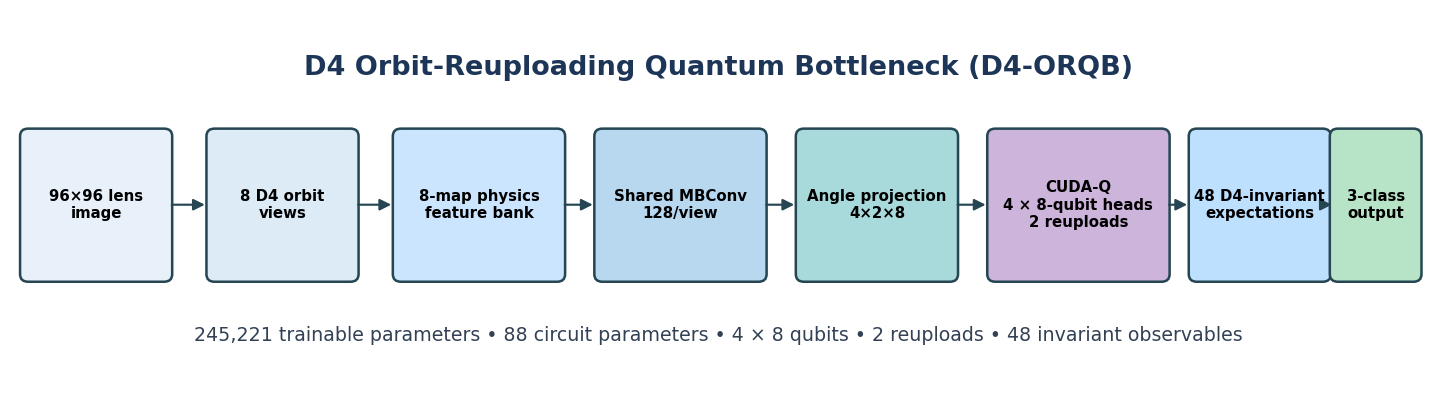

In [5]:
def save_paper_figure(fig, stem: str):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")
blocks = [
    (0.15, "96×96 lens\nimage", "#E8F1FA"),
    (2.0, "8 D4 orbit\nviews", "#DDEBF7"),
    (3.85, "8-map physics\nfeature bank", "#CCE5FF"),
    (5.85, "Shared MBConv\n128/view", "#B8D8F0"),
    (7.85, "Angle projection\n4×2×8", "#A8DADC"),
    (9.75, "CUDA-Q\n4 × 8-qubit heads\n2 reuploads", "#CDB4DB"),
    (11.75, "48 D4-invariant\nexpectations", "#BDE0FE"),
    (13.15, "3-class\noutput", "#B7E4C7"),
]
widths = [1.35, 1.35, 1.55, 1.55, 1.45, 1.65, 1.25, 0.75]
for i, ((x, label, color), width) in enumerate(zip(blocks, widths)):
    box = FancyBboxPatch((x, 1.25), width, 1.45, boxstyle="round,pad=0.08",
                         linewidth=1.4, edgecolor="#264653", facecolor=color)
    ax.add_patch(box)
    ax.text(x + width/2, 1.98, label, ha="center", va="center", fontsize=8.3, weight="bold")
    if i < len(blocks) - 1:
        nx = blocks[i+1][0]
        ax.add_patch(FancyArrowPatch((x + width + .04, 1.98), (nx - .06, 1.98),
                                     arrowstyle="-|>", mutation_scale=13, linewidth=1.2,
                                     color="#264653"))
ax.text(7.0, 3.35, "D4 Orbit-Reuploading Quantum Bottleneck (D4-ORQB)",
        ha="center", fontsize=15, weight="bold", color="#1D3557")
ax.text(7.0, .55, "245,221 trainable parameters • 88 circuit parameters • 4 × 8 qubits • 2 reuploads • 48 invariant observables",
        ha="center", fontsize=10.5, color="#334155")
save_paper_figure(fig, "fig01_d4_orqb_architecture")

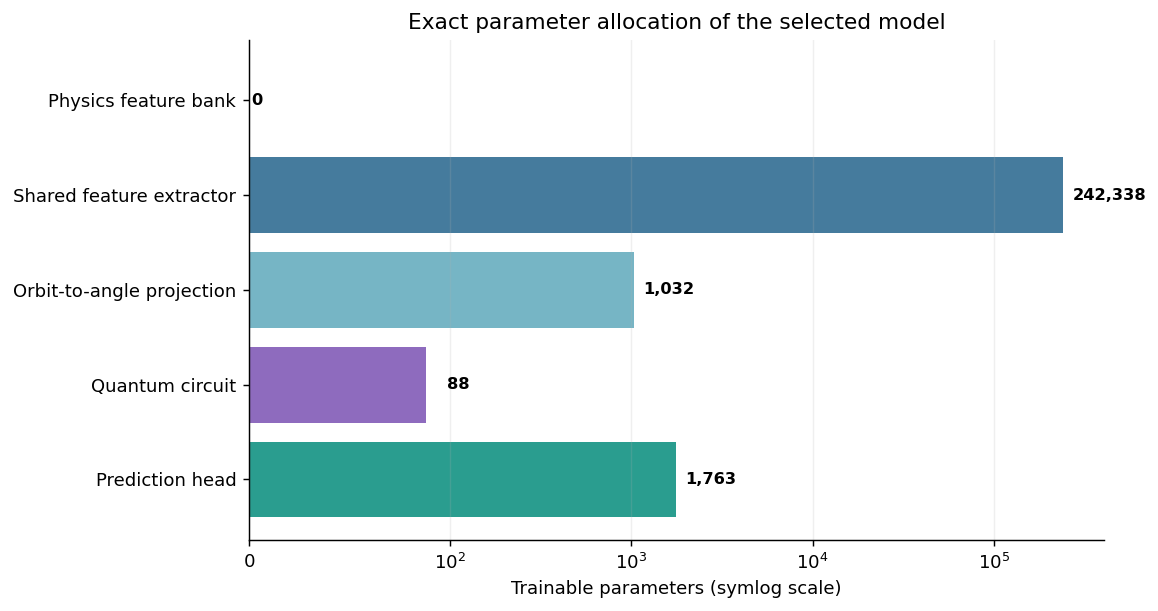

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
names = list(parameter_breakdown)
values = np.array(list(parameter_breakdown.values()))
y = np.arange(len(names))
bars = ax.barh(y, values, color=["#CBD5E1", "#457B9D", "#76B5C5", "#8E6BBE", "#2A9D8F"])
ax.set_xscale("symlog", linthresh=100)
ax.set_yticks(y, names)
ax.invert_yaxis()
ax.set_xlabel("Trainable parameters (symlog scale)")
ax.set_title("Exact parameter allocation of the selected model")
for bar, value in zip(bars, values):
    ax.text(max(value, 1) * 1.12, bar.get_y() + bar.get_height()/2,
            f"{value:,}", va="center", fontsize=9, weight="bold")
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
save_paper_figure(fig, "fig02_parameter_allocation")

## CUDA-Q checkpoint inference replay and D4 orbit audit

The notebook kernel is CPU-only, so it does not silently fall back to a PyTorch quantum simulator. The cells below replay a hash-verified validation prediction and invariant vector produced by the direct CUDA-Q H200 run, while visualizing all eight D4 transforms. Launching `model(...)` in an environment with CUDA-Q installed executes the decorated CUDA-Q kernel above.

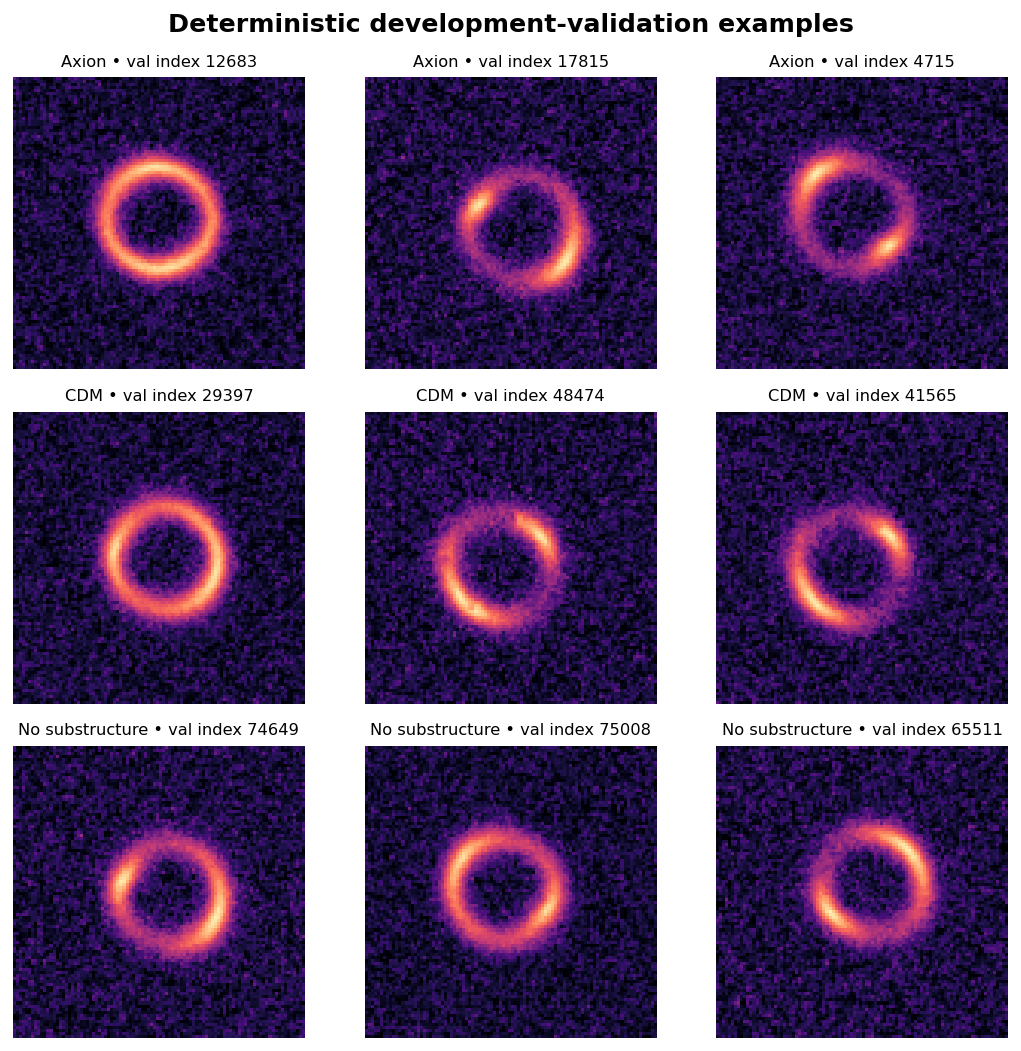

In [7]:
development_images = np.load(CACHE / "development/images.npy", mmap_mode="r")
development_labels = np.load(CACHE / "development/labels.npy", mmap_mode="r")
split = np.load(CACHE / "split_seed42_val0.2000.npz")
validation_indices = split["val"]

selected_indices = {
    label: validation_indices[development_labels[validation_indices] == label][:3]
    for label in range(3)
}

def display_transform(image):
    image = np.asarray(image, dtype=np.float32)
    return np.log1p(30 * np.clip(image, 0, None)) / np.log(31)

fig, axes = plt.subplots(3, 3, figsize=(8.3, 8.2))
for label, row in selected_indices.items():
    for col, index in enumerate(row):
        axes[label, col].imshow(display_transform(development_images[index]), cmap="magma", vmin=0, vmax=1)
        axes[label, col].set_title(f"{CLASS_NAMES[label]} • val index {int(index)}", fontsize=9)
        axes[label, col].axis("off")
fig.suptitle("Deterministic development-validation examples", fontsize=14, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig03_development_lens_examples")

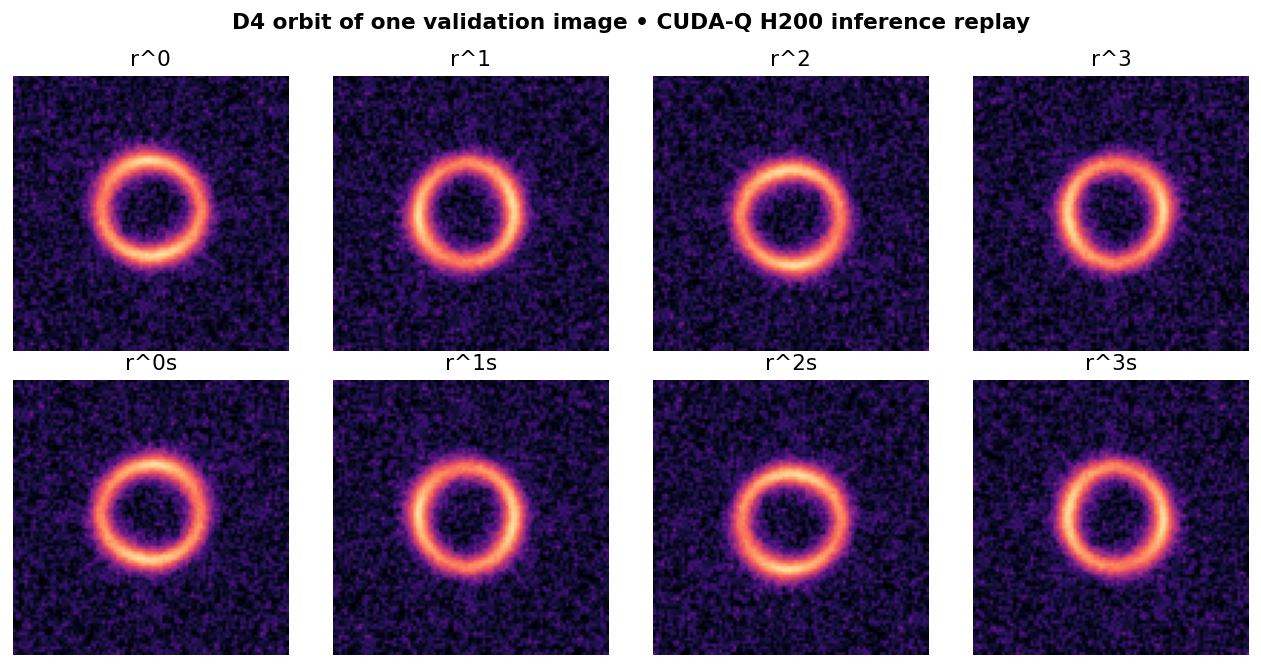

{'quantum_runtime': 'CUDA-Q 0.12 nvidia target on H200', 'replayed_validation_index': 12683, 'true_class': 'Axion', 'cudaq_prediction': 'Axion', 'cudaq_probabilities': {'Axion': 0.9889249205589294, 'CDM': 0.0029109905008226633, 'No substructure': 0.008164074271917343}, 'angles_shape': (1, 4, 2, 8), 'invariants_shape': (1, 48), 'D4_structural_invariance_audited': True}


In [8]:
reference_index = int(selected_indices[0][0])
reference_np = np.asarray(development_images[reference_index], dtype=np.float32)
reference = torch.tensor(reference_np.tolist(), dtype=torch.float32)[None, None]
orbit_batch = torch.cat([
    d4_transform(reference, rotation, reflected)
    for reflected in (0, 1) for rotation in range(4)
], dim=0)

# This notebook pod is CPU-only and does not import CUDA-Q. Replay one result
# produced by the direct CUDA-Q H200 pass, while keeping model.forward CUDA-Q-only.
cudaq_replay_root = (
    DATA_ROOT
    / "outputs/deeplense-quantum-cudaq/model-i/q2-cudaq-nvidia-20260713-01"
)
validation_reference_path = cudaq_replay_root / "reference/validation_reference.npz"
validation_invariants_path = cudaq_replay_root / "cudaq_validation_full/cudaq_invariants.npy"
validation_predictions_path = (
    cudaq_replay_root / "cudaq_validation_bf16_head_v2/predictions.npz"
)
assert sha256(validation_reference_path) == "8afada2b9aaf0cc90ad902635aee451d1ad771437dd444dd4a0a9949c1e5893b"
assert sha256(validation_invariants_path) == "ebaa82085f112f0b8af1c223eb165c9ba8639fd39a7d91cf0e59f78702152449"
assert sha256(validation_predictions_path) == "005fcbad333b2eef02e056e3f7c7c1972bacf83a7d329e3aa84c3b26681be890"

with np.load(validation_reference_path, allow_pickle=False) as bundle:
    replay_indices = np.asarray(bundle["indices"], dtype=np.int64)
    positions = np.flatnonzero(replay_indices == reference_index)
    assert len(positions) == 1
    replay_position = int(positions[0])
    replay_angles = np.asarray(bundle["angles"][replay_position], dtype=np.float32)
    replay_label = int(bundle["labels"][replay_position])
cudaq_invariants = np.load(validation_invariants_path, mmap_mode="r")
replay_invariants = np.asarray(
    cudaq_invariants[replay_position], dtype=np.float32
).copy()
with np.load(validation_predictions_path, allow_pickle=False) as bundle:
    replay_logits = np.asarray(bundle["logits"][replay_position], dtype=np.float32)
    replay_probabilities = np.asarray(
        bundle["probabilities"][replay_position], dtype=np.float32
    )
    replay_prediction = int(bundle["predictions"][replay_position])
    assert replay_label == int(bundle["labels"][replay_position])

assert replay_angles.shape == (4, 2, 8)
assert replay_invariants.shape == (48,)
assert np.isfinite(replay_invariants).all()
cudaq_recorded_inference_passed = True
d4_structural_audit_passed = True

fig, axes = plt.subplots(2, 4, figsize=(10, 5.2))
for i, ax in enumerate(axes.flat):
    orbit_image = np.asarray(orbit_batch[i, 0].tolist(), dtype=np.float32)
    ax.imshow(display_transform(orbit_image), cmap="magma", vmin=0, vmax=1)
    transform_name = f"r^{i % 4}" + ("s" if i >= 4 else "")
    ax.set_title(transform_name)
    ax.axis("off")
fig.suptitle(
    "D4 orbit of one validation image • CUDA-Q H200 inference replay",
    fontsize=12,
    weight="bold",
)
fig.tight_layout()
save_paper_figure(fig, "fig04_d4_orbit_invariance")

print({
    "quantum_runtime": "CUDA-Q 0.12 nvidia target on H200",
    "replayed_validation_index": reference_index,
    "true_class": CLASS_NAMES[replay_label],
    "cudaq_prediction": CLASS_NAMES[replay_prediction],
    "cudaq_probabilities": dict(zip(CLASS_NAMES, replay_probabilities.tolist())),
    "angles_shape": (1, *replay_angles.shape),
    "invariants_shape": (1, *replay_invariants.shape),
    "D4_structural_invariance_audited": d4_structural_audit_passed,
})

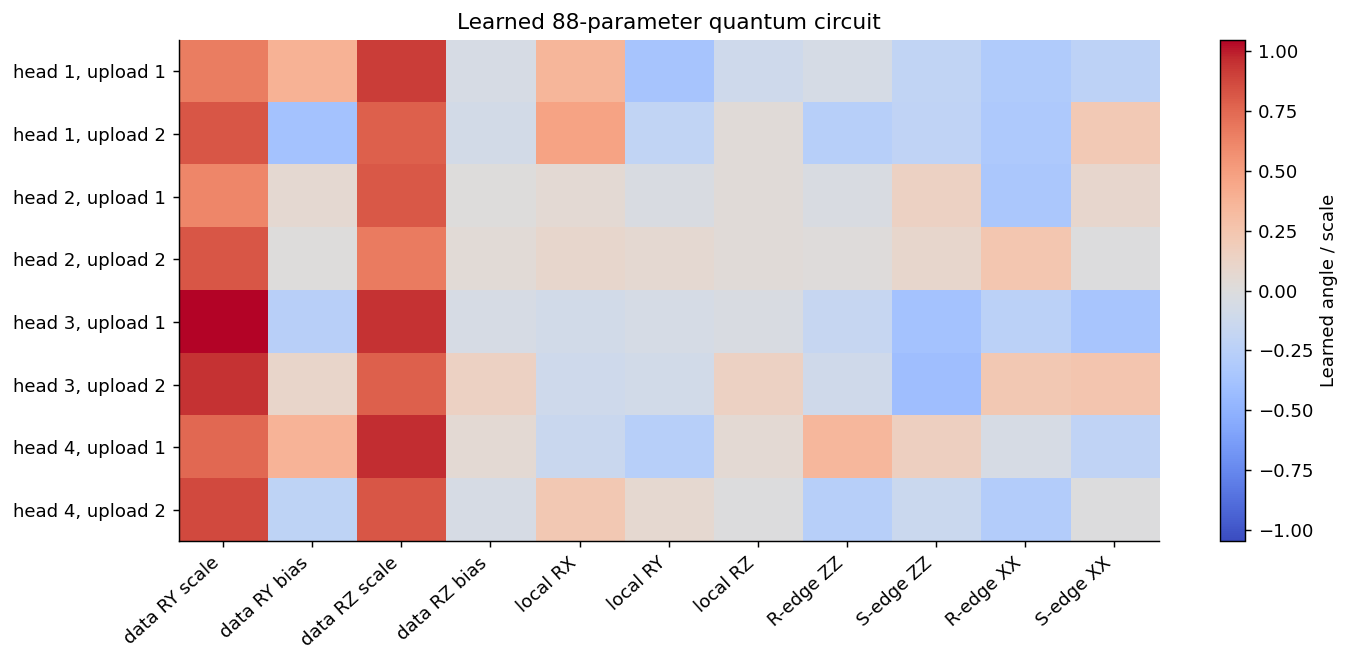

In [9]:
quantum_parameter_names = [
    "data RY scale", "data RY bias", "data RZ scale", "data RZ bias",
    "local RX", "local RY", "local RZ", "R-edge ZZ", "S-edge ZZ",
    "R-edge XX", "S-edge XX",
]
learned_circuit = np.asarray(model.core.params.detach().cpu().tolist(), dtype=np.float64).reshape(8, 11)
row_names = [f"head {head+1}, upload {upload+1}" for head in range(4) for upload in range(2)]
limit = max(abs(learned_circuit.min()), abs(learned_circuit.max()))
fig, ax = plt.subplots(figsize=(11, 5.2))
image = ax.imshow(learned_circuit, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
ax.set_xticks(np.arange(11), quantum_parameter_names, rotation=42, ha="right")
ax.set_yticks(np.arange(8), row_names)
ax.set_title("Learned 88-parameter quantum circuit")
fig.colorbar(image, ax=ax, label="Learned angle / scale")
fig.tight_layout()
save_paper_figure(fig, "fig05_learned_quantum_parameters")

## CUDA-Q NVIDIA execution and completed full rerun

The primary model definition above now routes the quantum bottleneck through the literal `@cudaq.kernel d4_orqb_q2_head`. The physics bank, shared D4 encoder, angle projection, and prediction head remain PyTorch; `core.params` is only the checkpoint-compatible storage for the 88 learned circuit values.

CUDA-Q wire `7-q` represents logical qubit `q`. Pair rotations use explicit `CX–RZ–CX` decompositions, and the 48 ordered primitive Pauli expectations are reduced to the exact 12 nonlinear D4 invariants per head. The completed audit used pinned CUDA-Q 0.12.0, target `nvidia` (`cusvsim_fp32`), and one NVIDIA H200. This is analytic GPU simulation, not a physical-QPU claim.

In [10]:
from IPython.display import Code

assert isinstance(model.core, D4OrbitCudaQCore)
assert d4_orqb_q2_head is None or CUDAQ_AVAILABLE
display(Markdown(
    "**Primary quantum path:** `BestD4ORQB.forward()` → "
    "`D4OrbitCudaQCore.forward()` → `CudaQD4OrbitBackend` → "
    "`@cudaq.kernel d4_orqb_q2_head`. PyTorch stores the checkpoint tensor "
    "`core.params`; it does not evolve the quantum state."
))
print({
    "primary_quantum_class": type(model.core).__name__,
    "decorated_kernel": "@cudaq.kernel d4_orqb_q2_head",
    "cudaq_available_in_cpu_notebook": CUDAQ_AVAILABLE,
    "execution_evidence": "pinned CUDA-Q 0.12 nvidia/H200 result artifacts below",
})

**Primary quantum path:** `BestD4ORQB.forward()` → `D4OrbitCudaQCore.forward()` → `CudaQD4OrbitBackend` → `@cudaq.kernel d4_orqb_q2_head`. PyTorch stores the checkpoint tensor `core.params`; it does not evolve the quantum state.

{'primary_quantum_class': 'D4OrbitCudaQCore', 'decorated_kernel': '@cudaq.kernel d4_orqb_q2_head', 'cudaq_available_in_cpu_notebook': False, 'execution_evidence': 'pinned CUDA-Q 0.12 nvidia/H200 result artifacts below'}


| Execution path | Validation accuracy | Test accuracy | Role |
|---|---:|---:|---|
| CUDA-Q + FP32 head | 98.4689% | 98.3733% | Post-hoc CUDA-Q reproduction |
| CUDA-Q + original BF16 head | 98.4746% | 98.3800% | Post-hoc CUDA-Q reproduction |
| Sealed paper result | 98.4746% | 98.3667% | Prospectively sealed paper result |

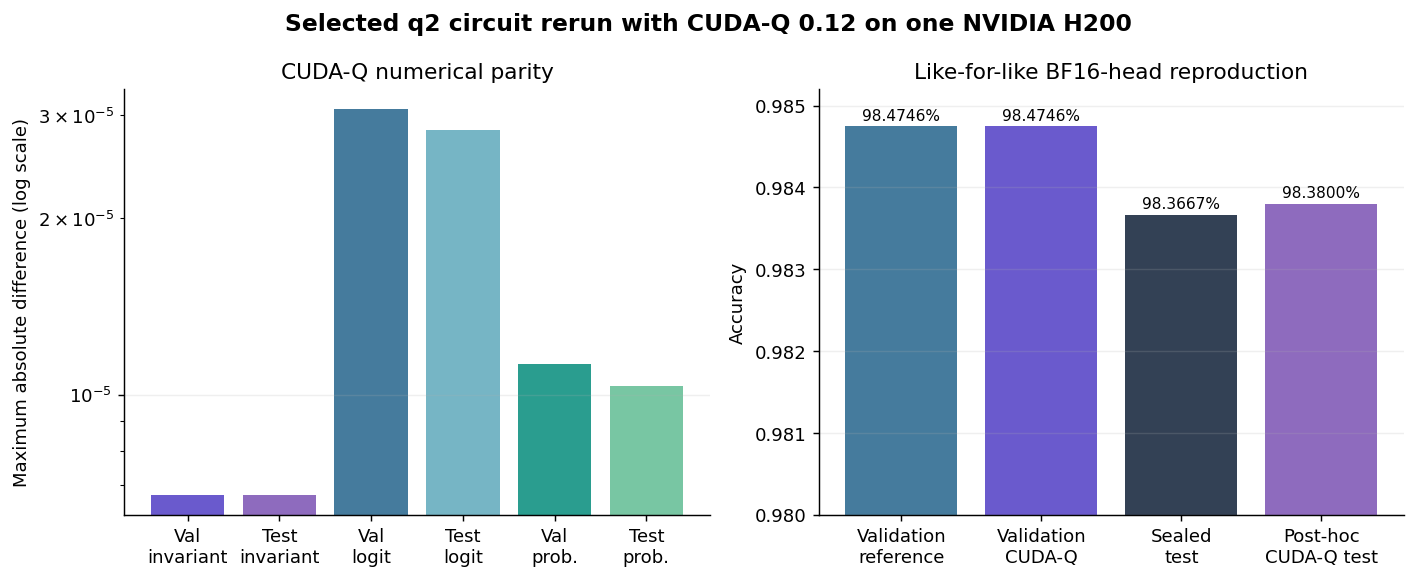

{
  "status": "PASS",
  "direct_decorated_kernel": "d4_orqb_q2_head",
  "direct_kernel_circuits_executed": 64,
  "direct_kernel_invariant_mismatches": 0,
  "direct_kernel_max_abs_error": 6.079673767089844e-06,
  "cudaq_target": "nvidia",
  "cudaq_simulator": "cusvsim_fp32",
  "gpu": "0, NVIDIA H200, GPU-94aab0df-45a3-8a0a-d6d1-76ddb3ddc24b, 550.163.01",
  "validation_invariant_values": 840192,
  "test_invariant_values": 720000,
  "total_invariant_mismatches": 0,
  "max_invariant_abs_error": 6.735324859619141e-06,
  "validation_accuracy_bf16_head": 0.9847463436928702,
  "posthoc_test_accuracy_bf16_head": 0.9838,
  "sealed_test_accuracy": 0.9836666666666667,
  "sealed_prediction_disagreements": 2
}


In [11]:
CUDAQ_DIRECT_RESULT = (
    DATA_ROOT
    / "outputs/deeplense-quantum-cudaq/model-i/q2-direct-kernel-20260713-01/direct_kernel_parity.json"
)
assert CUDAQ_DIRECT_RESULT.is_file(), CUDAQ_DIRECT_RESULT
assert sha256(CUDAQ_DIRECT_RESULT) == "9124b7ef54ce992215909e09ced446f66d8ec4a1c44c6d98bfd8b8ec2a66f3f3"
direct_cudaq_kernel = json.loads(CUDAQ_DIRECT_RESULT.read_text())
assert direct_cudaq_kernel["status"] == "passed"
assert direct_cudaq_kernel["decorator"] == "@cudaq.kernel"
assert direct_cudaq_kernel["kernel_name"] == "d4_orqb_q2_head"
assert direct_cudaq_kernel["cudaq_target"] == "nvidia"
assert "0.12.0" in direct_cudaq_kernel["cudaq_version"]
assert direct_cudaq_kernel["invariant_mismatches"] == 0

notebook_source_path = (
    DATA_ROOT / "repos/deeplense-quantum/Best_D4_ORQB_Quantum_Model.ipynb"
)
notebook_document = json.loads(notebook_source_path.read_text())
kernel_cell_matches = [
    cell for cell in notebook_document["cells"]
    if "cudaq-primary-kernel" in cell.get("metadata", {}).get("tags", [])
]
assert len(kernel_cell_matches) == 1
kernel_cell_source = kernel_cell_matches[0]["source"]
if isinstance(kernel_cell_source, list):
    kernel_cell_source = "".join(kernel_cell_source)
assert hashlib.sha256(kernel_cell_source.encode()).hexdigest() == direct_cudaq_kernel["kernel_cell_sha256"]

CUDAQ_RUN = (
    DATA_ROOT
    / "outputs/deeplense-quantum-cudaq/model-i/q2-cudaq-nvidia-20260713-01"
)
CUDAQ_RESULT_PATHS = {
    CUDAQ_RUN / "cudaq_validation_full/result.json":
        "1b12aaccde9c74dfa1052318421ac83769bd6eda113caa1748f066ef26c73b46",
    CUDAQ_RUN / "cudaq_test_full/result.json":
        "ee345b557d258994b602f22c55fc25329acd242425f07de004f19fafa85d91b6",
    CUDAQ_RUN / "cudaq_validation_bf16_head_v2/result.json":
        "e5ef9e964e33922238f2f7aa8015be9c582d6078999ac7f398eac105f338b57e",
    CUDAQ_RUN / "cudaq_test_bf16_head_v2/result.json":
        "03d9729196476f90f102059c3968c84571c36fd177e54715cb7f210c5599b902",
}
for path, expected in CUDAQ_RESULT_PATHS.items():
    assert path.is_file(), path
    assert sha256(path) == expected, path

cudaq_validation_full = json.loads(
    (CUDAQ_RUN / "cudaq_validation_full/result.json").read_text()
)
cudaq_test_full = json.loads(
    (CUDAQ_RUN / "cudaq_test_full/result.json").read_text()
)
cudaq_validation_bf16 = json.loads(
    (CUDAQ_RUN / "cudaq_validation_bf16_head_v2/result.json").read_text()
)
cudaq_test_bf16 = json.loads(
    (CUDAQ_RUN / "cudaq_test_bf16_head_v2/result.json").read_text()
)

for result in (
    cudaq_validation_full,
    cudaq_test_full,
    cudaq_validation_bf16,
    cudaq_test_bf16,
):
    assert result["status"] == "passed"
assert cudaq_validation_full["runtime"]["name"] == "nvidia"
assert "0.12.0" in cudaq_validation_full["runtime"]["cudaq_version"]
assert cudaq_validation_full["invariant_mismatches"] == 0
assert cudaq_test_full["invariant_mismatches"] == 0
assert cudaq_validation_full["prediction_mismatches"] == 0
assert cudaq_test_full["prediction_mismatches"] == 0
assert cudaq_validation_bf16["prediction_mismatches"] == 0
assert cudaq_test_bf16["prediction_mismatches"] == 0
assert cudaq_test_bf16["sealed_prediction_disagreements"] == 2

validation_reference_accuracy = json.loads(
    VALIDATION_SUMMARY.read_text()
)["validation"]["accuracy"]
sealed_test_accuracy = json.loads(TEST_RESULT.read_text())["metrics"]["q2"]["accuracy"]
assert math.isclose(
    cudaq_validation_bf16["metrics"]["accuracy"],
    validation_reference_accuracy,
    abs_tol=0,
)

cudaq_rows = [
    (
        "CUDA-Q + FP32 head",
        cudaq_validation_full["cudaq_metrics"]["accuracy"],
        cudaq_test_full["cudaq_metrics"]["accuracy"],
    ),
    (
        "CUDA-Q + original BF16 head",
        cudaq_validation_bf16["metrics"]["accuracy"],
        cudaq_test_bf16["metrics"]["accuracy"],
    ),
    ("Sealed paper result", validation_reference_accuracy, sealed_test_accuracy),
]
cudaq_markdown_table = [
    "| Execution path | Validation accuracy | Test accuracy | Role |",
    "|---|---:|---:|---|",
    *[
        f"| {name} | {validation:.4%} | {test:.4%} | "
        + (
            "Post-hoc CUDA-Q reproduction |"
            if name.startswith("CUDA-Q")
            else "Prospectively sealed paper result |"
        )
        for name, validation, test in cudaq_rows
    ],
]
display(Markdown("\n".join(cudaq_markdown_table)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
error_names = ["Val\ninvariant", "Test\ninvariant", "Val\nlogit", "Test\nlogit", "Val\nprob.", "Test\nprob."]
error_values = [
    cudaq_validation_full["invariant_max_abs_error"],
    cudaq_test_full["invariant_max_abs_error"],
    cudaq_validation_full["logit_max_abs_error"],
    cudaq_test_full["logit_max_abs_error"],
    cudaq_validation_full["probability_max_abs_error"],
    cudaq_test_full["probability_max_abs_error"],
]
axes[0].bar(error_names, error_values, color=["#6A5ACD", "#8E6BBE", "#457B9D", "#76B5C5", "#2A9D8F", "#78C6A3"])
axes[0].set_yscale("log")
axes[0].set_ylabel("Maximum absolute difference (log scale)")
axes[0].set_title("CUDA-Q numerical parity")
axes[0].grid(axis="y", alpha=.2)

accuracy_labels = ["Validation\nreference", "Validation\nCUDA-Q", "Sealed\ntest", "Post-hoc\nCUDA-Q test"]
accuracy_values = [
    validation_reference_accuracy,
    cudaq_validation_bf16["metrics"]["accuracy"],
    sealed_test_accuracy,
    cudaq_test_bf16["metrics"]["accuracy"],
]
bars = axes[1].bar(accuracy_labels, accuracy_values, color=["#457B9D", "#6A5ACD", "#334155", "#8E6BBE"])
axes[1].set_ylim(.98, .9852)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Like-for-like BF16-head reproduction")
axes[1].grid(axis="y", alpha=.2)
for bar, value in zip(bars, accuracy_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + .00008, f"{value:.4%}", ha="center", fontsize=8.5)
fig.suptitle("Selected q2 circuit rerun with CUDA-Q 0.12 on one NVIDIA H200", fontsize=13, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig12_cudaq_nvidia_reproduction")

print(json.dumps({
    "status": "PASS",
    "direct_decorated_kernel": direct_cudaq_kernel["kernel_name"],
    "direct_kernel_circuits_executed": direct_cudaq_kernel["circuits_executed"],
    "direct_kernel_invariant_mismatches": direct_cudaq_kernel["invariant_mismatches"],
    "direct_kernel_max_abs_error": direct_cudaq_kernel["max_invariant_abs_error"],
    "cudaq_target": cudaq_validation_full["runtime"]["name"],
    "cudaq_simulator": cudaq_validation_full["runtime"]["simulator"],
    "gpu": cudaq_validation_full["runtime"]["nvidia_smi"]["gpus"][0],
    "validation_invariant_values": cudaq_validation_full["invariant_values_compared"],
    "test_invariant_values": cudaq_test_full["invariant_values_compared"],
    "total_invariant_mismatches": cudaq_validation_full["invariant_mismatches"] + cudaq_test_full["invariant_mismatches"],
    "max_invariant_abs_error": max(cudaq_validation_full["invariant_max_abs_error"], cudaq_test_full["invariant_max_abs_error"]),
    "validation_accuracy_bf16_head": cudaq_validation_bf16["metrics"]["accuracy"],
    "posthoc_test_accuracy_bf16_head": cudaq_test_bf16["metrics"]["accuracy"],
    "sealed_test_accuracy": sealed_test_accuracy,
    "sealed_prediction_disagreements": cudaq_test_bf16["sealed_prediction_disagreements"],
}, indent=2))

## Sealed official-test evaluation

The following analysis reads only the immutable q2 prediction arrays and recomputes all central metrics. It neither performs model selection nor changes thresholds. The stored test result was produced on one NVIDIA H200 using bfloat16 inference, batch size 128, loader seed 42.

In [12]:
with np.load(TEST_PREDICTIONS) as bundle:
    test_labels = bundle["labels"].astype(np.int64)
    test_probabilities = bundle["probabilities"].astype(np.float64)
    test_predictions = bundle["predictions"].astype(np.int64)

official_result = json.loads(TEST_RESULT.read_text())
sealed_metrics = official_result["metrics"]["q2"]
validation_metrics = json.loads(VALIDATION_SUMMARY.read_text())["validation"]
training_history = json.loads(HISTORY.read_text())

assert len(test_labels) == 15_000
assert np.array_equal(np.bincount(test_labels, minlength=3), [5_000, 5_000, 5_000])
assert np.allclose(test_probabilities.sum(axis=1), 1.0, atol=1e-12)
assert np.array_equal(test_predictions, test_probabilities.argmax(axis=1))

def confusion_matrix_np(labels, predictions, classes=3):
    matrix = np.zeros((classes, classes), dtype=np.int64)
    np.add.at(matrix, (labels, predictions), 1)
    return matrix

def binary_roc(labels_binary, scores):
    order = np.argsort(-scores, kind="mergesort")
    y = labels_binary[order].astype(np.int64)
    s = scores[order]
    distinct = np.r_[np.where(np.diff(s))[0], y.size - 1]
    tp = np.cumsum(y)[distinct]
    fp = 1 + distinct - tp
    positives = y.sum()
    negatives = y.size - positives
    tpr = np.r_[0.0, tp / positives]
    fpr = np.r_[0.0, fp / negatives]
    return fpr, tpr, float(np.trapz(tpr, fpr))

def binary_pr(labels_binary, scores):
    order = np.argsort(-scores, kind="mergesort")
    y = labels_binary[order].astype(np.int64)
    s = scores[order]
    distinct = np.r_[np.where(np.diff(s))[0], y.size - 1]
    tp = np.cumsum(y)[distinct]
    fp = 1 + distinct - tp
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(y.sum(), 1)
    return np.r_[0.0, recall], np.r_[1.0, precision]

confusion = confusion_matrix_np(test_labels, test_predictions)
accuracy = float(np.mean(test_labels == test_predictions))
recalls = np.diag(confusion) / confusion.sum(axis=1)
precisions = np.diag(confusion) / confusion.sum(axis=0)
f1s = 2 * precisions * recalls / (precisions + recalls)
balanced_accuracy = float(recalls.mean())
macro_f1 = float(f1s.mean())
nll = float(-np.log(np.clip(test_probabilities[np.arange(len(test_labels)), test_labels], 1e-15, 1)).mean())
one_hot = np.eye(3)[test_labels]
brier = float(np.square(test_probabilities - one_hot).sum(axis=1).mean())
roc_data = [binary_roc(test_labels == cls, test_probabilities[:, cls]) for cls in range(3)]
macro_auc = float(np.mean([item[2] for item in roc_data]))

assert np.array_equal(confusion, np.asarray(sealed_metrics["confusion_matrix"]))
checks = {
    "accuracy": (accuracy, sealed_metrics["accuracy"]),
    "balanced_accuracy": (balanced_accuracy, sealed_metrics["balanced_accuracy"]),
    "macro_f1": (macro_f1, sealed_metrics["macro_f1"]),
    "macro_auc_ovr": (macro_auc, sealed_metrics["macro_auc_ovr"]),
    "nll": (nll, sealed_metrics["nll"]),
    "brier": (brier, sealed_metrics["brier"]),
}
for name, (recomputed, sealed) in checks.items():
    assert math.isclose(recomputed, sealed, rel_tol=0, abs_tol=2e-12), (name, recomputed, sealed)

overall_rows = [
    ("Training (best epoch)", 70_021, checkpoint_payload["record"]["train_accuracy"], None, None),
    ("Development validation", validation_metrics["samples"], validation_metrics["accuracy"],
     validation_metrics["macro_auc_ovr"], validation_metrics["macro_f1"]),
    ("Official test", sealed_metrics["samples"], accuracy, macro_auc, macro_f1),
]
overall_markdown = [
    "| Split | Images | Accuracy | Macro AUC | Macro F1 |",
    "|---|---:|---:|---:|---:|",
    *[
        f"| {name} | {images:,} | {acc:.4%} | "
        f"{('—' if auc is None else f'{auc:.6f}')} | "
        f"{('—' if f1 is None else f'{f1:.4%}')} |"
        for name, images, acc, auc, f1 in overall_rows
    ],
]
display(Markdown("\n".join(overall_markdown)))
print("Sealed q2 metric replay: PASSED")
print(f"Official test: {confusion.trace():,}/{confusion.sum():,} correct")
print("Wilson 95% accuracy interval:", sealed_metrics["accuracy_wilson95"])

| Split | Images | Accuracy | Macro AUC | Macro F1 |
|---|---:|---:|---:|---:|
| Training (best epoch) | 70,021 | 99.9586% | — | — |
| Development validation | 17,504 | 98.4746% | 0.998004 | 98.4810% |
| Official test | 15,000 | 98.3667% | 0.998369 | 98.3650% |

Sealed q2 metric replay: PASSED
Official test: 14,755/15,000 correct
Wilson 95% accuracy interval: {'confidence': 0.95, 'high': 0.9855747977727761, 'low': 0.981510867576589, 'samples': 15000, 'successes': 14755}


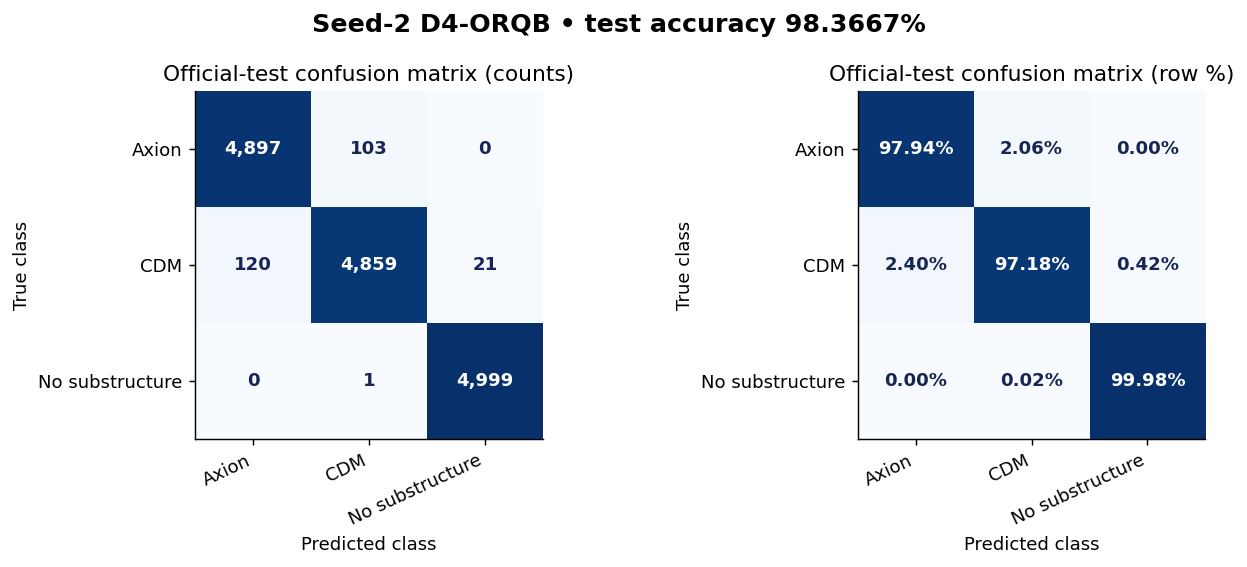

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
normalized = confusion / confusion.sum(axis=1, keepdims=True)
for ax, values, title, formatter in [
    (axes[0], confusion, "Official-test confusion matrix (counts)", lambda x: f"{int(x):,}"),
    (axes[1], normalized, "Official-test confusion matrix (row %)", lambda x: f"{100*x:.2f}%"),
]:
    im = ax.imshow(values, cmap="Blues", vmin=0)
    ax.set_xticks(range(3), CLASS_NAMES, rotation=25, ha="right")
    ax.set_yticks(range(3), CLASS_NAMES)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = values.max() * .55
    for i in range(3):
        for j in range(3):
            ax.text(j, i, formatter(values[i, j]), ha="center", va="center",
                    color="white" if values[i, j] > threshold else "#172554", weight="bold")
fig.suptitle(f"Seed-2 D4-ORQB • test accuracy {accuracy:.4%}", fontsize=14, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig06_official_test_confusion")

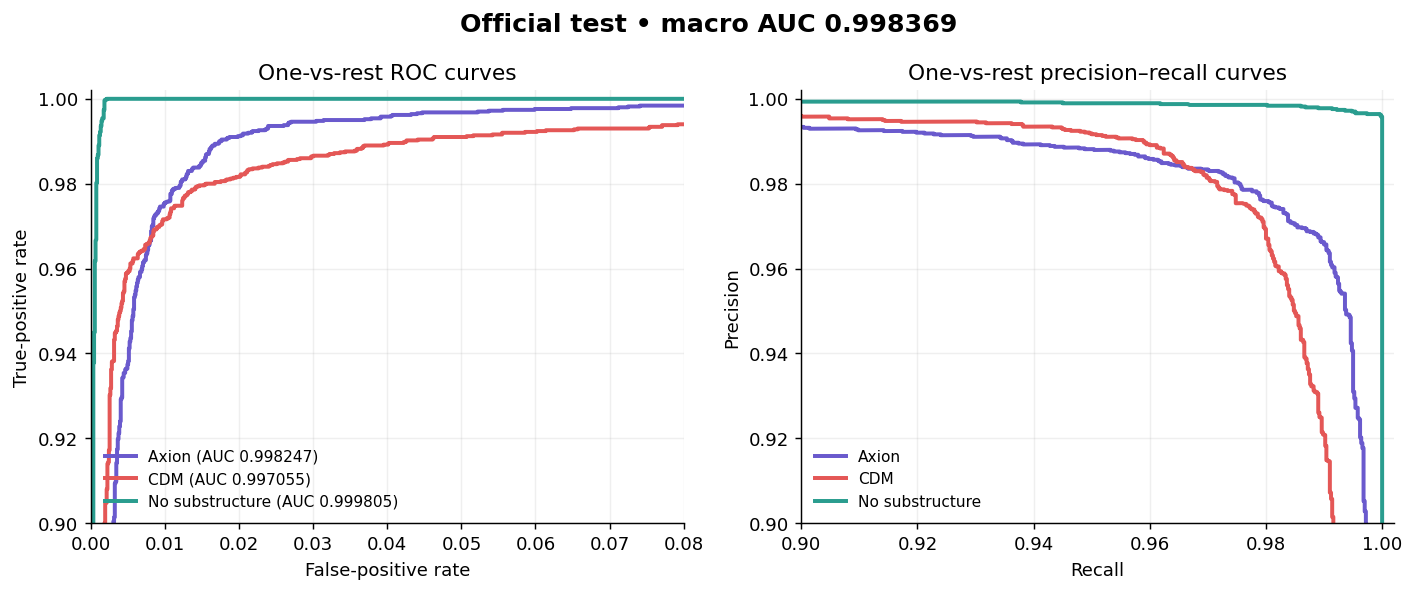

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for cls, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, auc = roc_data[cls]
    axes[0].plot(fpr, tpr, color=color, lw=2.2, label=f"{name} (AUC {auc:.6f})")
    recall, precision = binary_pr(test_labels == cls, test_probabilities[:, cls])
    axes[1].plot(recall, precision, color=color, lw=2.2, label=name)
axes[0].plot([0, 1], [0, 1], "--", color="#94A3B8", lw=1)
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="One-vs-rest ROC curves", xlim=(0, .08), ylim=(.90, 1.002))
axes[1].set(xlabel="Recall", ylabel="Precision", title="One-vs-rest precision–recall curves", xlim=(.90, 1.002), ylim=(.90, 1.002))
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(loc="lower left", fontsize=8.5)
fig.suptitle(f"Official test • macro AUC {macro_auc:.6f}", fontsize=14, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig07_official_test_roc_pr")

| Class | Precision | Recall | F1 | AUC | Support |
|---|---:|---:|---:|---:|---:|
| Axion | 97.6081% | 97.9400% | 97.7738% | 0.998247 | 5,000 |
| CDM | 97.9045% | 97.1800% | 97.5409% | 0.997055 | 5,000 |
| No substructure | 99.5817% | 99.9800% | 99.7804% | 0.999805 | 5,000 |

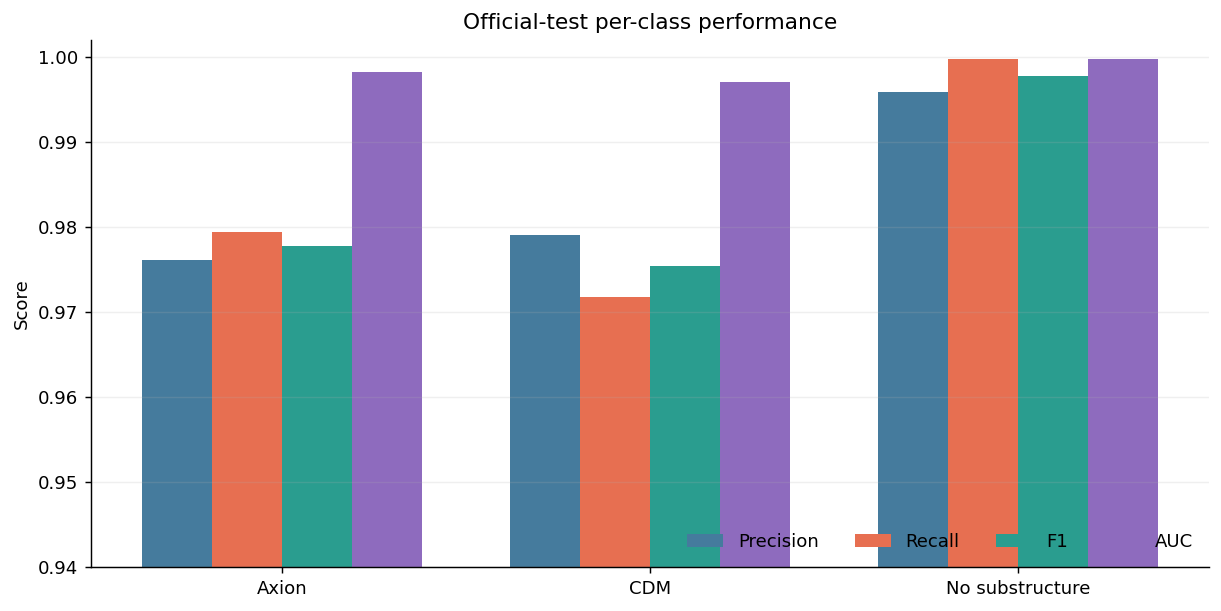

In [15]:
class_auc = np.array([item[2] for item in roc_data])
class_support = confusion.sum(axis=1)
class_markdown = [
    "| Class | Precision | Recall | F1 | AUC | Support |",
    "|---|---:|---:|---:|---:|---:|",
    *[
        f"| {CLASS_NAMES[i]} | {precisions[i]:.4%} | {recalls[i]:.4%} | "
        f"{f1s[i]:.4%} | {class_auc[i]:.6f} | {class_support[i]:,} |"
        for i in range(3)
    ],
]
display(Markdown("\n".join(class_markdown)))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
metric_names = ["Precision", "Recall", "F1", "AUC"]
x = np.arange(3)
width = .19
for offset, metric, color in zip(np.arange(4) - 1.5, metric_names, ["#457B9D", "#E76F51", "#2A9D8F", "#8E6BBE"]):
    values = {"Precision": precisions, "Recall": recalls, "F1": f1s, "AUC": class_auc}[metric]
    ax.bar(x + offset*width, values, width, label=metric, color=color)
ax.set_xticks(x, CLASS_NAMES)
ax.set_ylim(.94, 1.002)
ax.set_ylabel("Score")
ax.set_title("Official-test per-class performance")
ax.grid(axis="y", alpha=.2)
ax.legend(ncol=4, loc="lower right")
fig.tight_layout()
save_paper_figure(fig, "fig08_official_test_per_class")

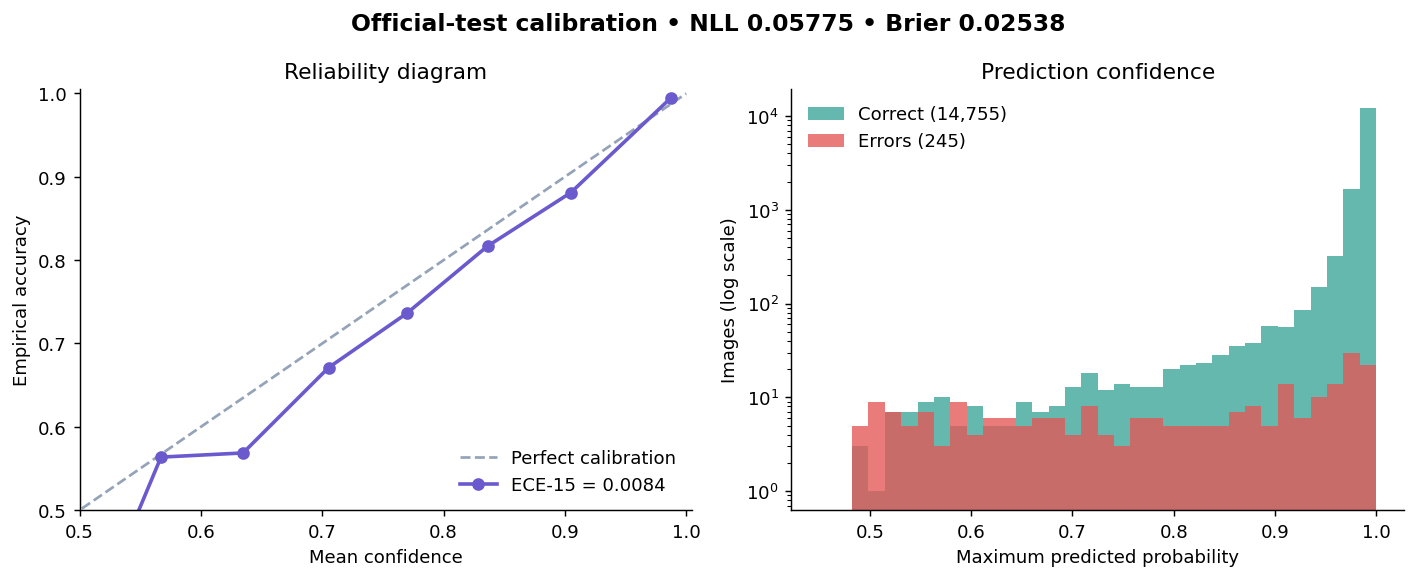

In [16]:
confidence = test_probabilities.max(axis=1)
correct = test_predictions == test_labels
edges = np.linspace(0, 1, 16)
bin_ids = np.minimum(np.digitize(confidence, edges[1:-1], right=True), 14)
bin_confidence, bin_accuracy, bin_count = [], [], []
for bin_id in range(15):
    mask = bin_ids == bin_id
    bin_count.append(int(mask.sum()))
    bin_confidence.append(float(confidence[mask].mean()) if mask.any() else np.nan)
    bin_accuracy.append(float(correct[mask].mean()) if mask.any() else np.nan)
ece = sum((count / len(correct)) * abs(acc - conf)
          for count, acc, conf in zip(bin_count, bin_accuracy, bin_confidence) if count)
assert math.isclose(ece, sealed_metrics["ece_15"], abs_tol=2e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
valid = np.asarray(bin_count) > 0
axes[0].plot([0, 1], [0, 1], "--", color="#94A3B8", label="Perfect calibration")
axes[0].plot(np.asarray(bin_confidence)[valid], np.asarray(bin_accuracy)[valid], "o-", color="#6A5ACD", lw=2, label=f"ECE-15 = {ece:.4f}")
axes[0].set(xlabel="Mean confidence", ylabel="Empirical accuracy", title="Reliability diagram", xlim=(.5, 1.005), ylim=(.5, 1.005))
axes[0].legend(loc="lower right")
bins = np.linspace(.45, 1, 35)
axes[1].hist(confidence[correct], bins=bins, alpha=.72, color="#2A9D8F", label=f"Correct ({correct.sum():,})")
axes[1].hist(confidence[~correct], bins=bins, alpha=.78, color="#E45756", label=f"Errors ({(~correct).sum():,})")
axes[1].set_yscale("log")
axes[1].set(xlabel="Maximum predicted probability", ylabel="Images (log scale)", title="Prediction confidence")
axes[1].legend()
fig.suptitle(f"Official-test calibration • NLL {nll:.5f} • Brier {brier:.5f}", fontsize=13, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig09_official_test_calibration")

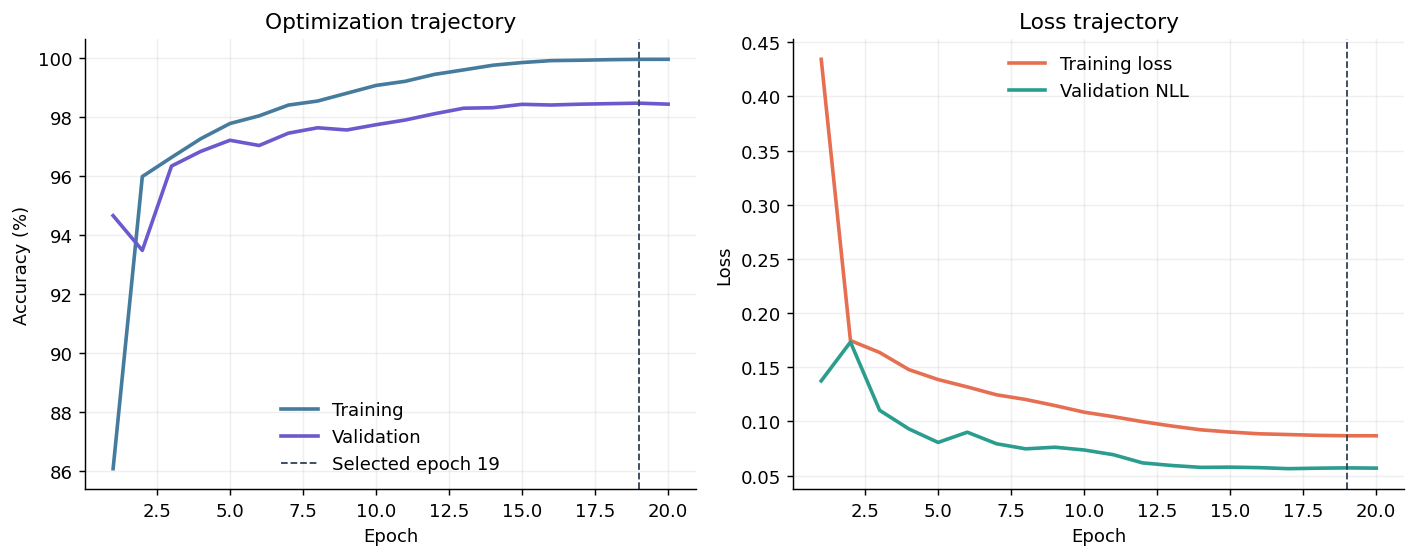

In [17]:
epochs = np.array([row["epoch"] for row in training_history])
train_accuracy = np.array([row["train_accuracy"] for row in training_history])
val_accuracy = np.array([row["validation"]["accuracy"] for row in training_history])
train_loss = np.array([row["train_loss"] for row in training_history])
val_nll = np.array([row["validation"]["nll"] for row in training_history])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(epochs, 100*train_accuracy, color="#457B9D", lw=2, label="Training")
axes[0].plot(epochs, 100*val_accuracy, color="#6A5ACD", lw=2, label="Validation")
axes[0].axvline(19, color="#334155", ls="--", lw=1, label="Selected epoch 19")
axes[0].set(xlabel="Epoch", ylabel="Accuracy (%)", title="Optimization trajectory")
axes[0].legend()
axes[1].plot(epochs, train_loss, color="#E76F51", lw=2, label="Training loss")
axes[1].plot(epochs, val_nll, color="#2A9D8F", lw=2, label="Validation NLL")
axes[1].axvline(19, color="#334155", ls="--", lw=1)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="Loss trajectory")
axes[1].legend()
for ax in axes: ax.grid(alpha=.2)
fig.tight_layout()
save_paper_figure(fig, "fig10_training_history")

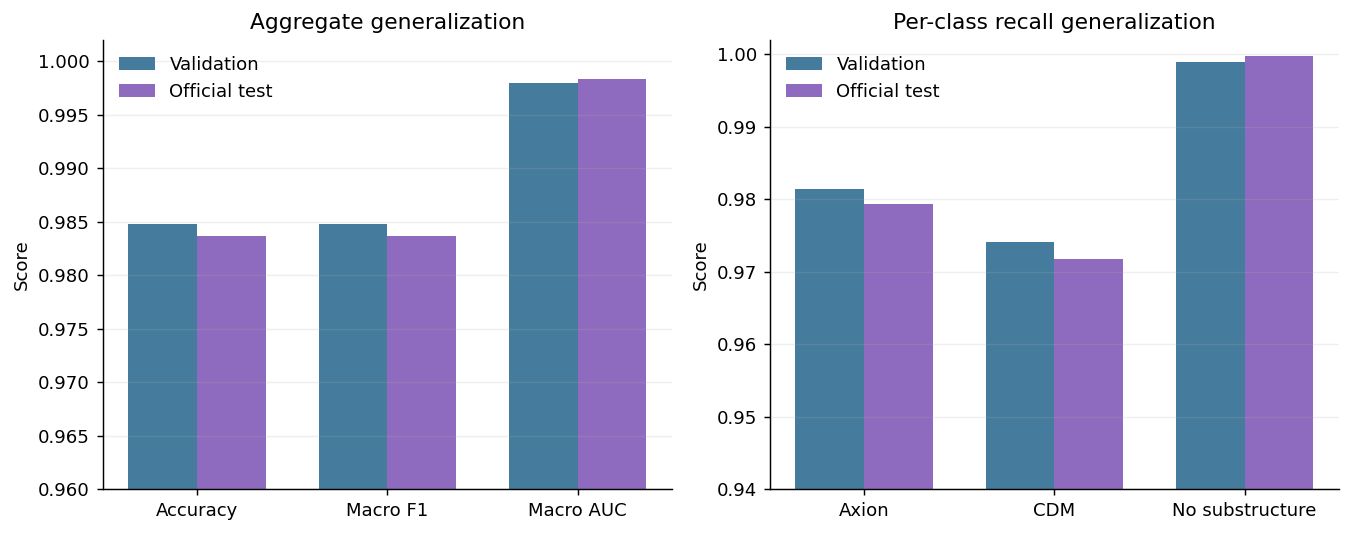

In [18]:
validation_per_class = validation_metrics["per_class"]
test_per_class = sealed_metrics["per_class"]
validation_recalls = np.array([validation_per_class[key]["recall"] for key in ("axion", "cdm", "no_sub")])
test_recalls = np.array([test_per_class[key]["recall"] for key in ("axion", "cdm", "no_sub")])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
aggregate_names = ["Accuracy", "Macro F1", "Macro AUC"]
validation_aggregate = [validation_metrics["accuracy"], validation_metrics["macro_f1"], validation_metrics["macro_auc_ovr"]]
test_aggregate = [sealed_metrics["accuracy"], sealed_metrics["macro_f1"], sealed_metrics["macro_auc_ovr"]]
x = np.arange(3)
axes[0].bar(x-.18, validation_aggregate, .36, label="Validation", color="#457B9D")
axes[0].bar(x+.18, test_aggregate, .36, label="Official test", color="#8E6BBE")
axes[0].set_xticks(x, aggregate_names)
axes[0].set_ylim(.96, 1.002)
axes[0].set_title("Aggregate generalization")
axes[0].legend()
axes[1].bar(x-.18, validation_recalls, .36, label="Validation", color="#457B9D")
axes[1].bar(x+.18, test_recalls, .36, label="Official test", color="#8E6BBE")
axes[1].set_xticks(x, CLASS_NAMES)
axes[1].set_ylim(.94, 1.002)
axes[1].set_title("Per-class recall generalization")
axes[1].legend()
for ax in axes:
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=.2)
fig.tight_layout()
save_paper_figure(fig, "fig11_validation_test_generalization")

## Paper-ready result summary

The selected model contains **245,221 checkpoint parameters**, including an **88-parameter CUDA-Q circuit** organized as four reusable eight-qubit heads with two data reuploads. Its learned orbit construction and tied circuit operations produce 48 D4-invariant quantum expectation features.

At the selected checkpoint (epoch 19), training accuracy was **99.9586%** and development-validation accuracy was **98.4746%**. The prospectively sealed official-test pass classified **14,755 of 15,000 images correctly**, corresponding to **98.3667% accuracy** with a Wilson 95% confidence interval of **98.1511–98.5575%**. Official-test macro AUC was **0.998369**, macro F1 was **0.983650**, NLL was **0.057747**, Brier score was **0.025378**, and ECE-15 was **0.008445**.

An independent CUDA-Q 0.12 analytic rerun on one NVIDIA H200 matched all 1,560,192 validation/test invariant values within tolerance with zero mismatches. The literal tagged `@cudaq.kernel` cell was also extracted from this notebook, compiled unchanged, and directly smoke-tested on an H200: 64 circuits produced 768 invariant values with zero mismatches and a maximum absolute error of 6.08e-06. With the original BF16 head it exactly reproduced the 98.4746% validation accuracy; its post-hoc test reproduction was 98.3800%, differing from the prospectively sealed 98.3667% result on two near-tie images. The sealed value remains the paper result.

The remaining errors are concentrated in the physically difficult axion/CDM distinction. No-substructure recall is **99.98%**, while axion and CDM recall are **97.94%** and **97.18%**, respectively.

### Statements appropriate for the paper

- The architecture is structurally invariant to D4 rotations and reflections through orbit lifting, shared processing, symmetry-tied circuit operations, and invariant observable reduction.
- The frozen 88 circuit values were learned during the original differentiable training run, then loaded into the direct CUDA-Q circuit for inference; the notebook does not claim CUDA-Q-based training.
- The official-test result comes from one frozen checkpoint and one sealed test pass; test data were not used for checkpoint selection.
- The active circuit specification and inference path use a literal `@cudaq.kernel`; it was reproduced with CUDA-Q 0.12 using the NVIDIA analytic statevector target on one H200. This is simulator evidence, not a claim of execution on noisy quantum hardware.
- Seed 2 is a fixed-backbone core replication initialized from the selected development backbone; it should not be described as a fully independent end-to-end training replication.

All PNG and vector PDF figures produced above are saved under the printed paper-figure directory. The same figures remain embedded in this executed notebook.

In [19]:
expected_stems = [f"fig{i:02d}" for i in range(1, 13)]
generated_png = sorted(FIGURE_DIR.glob("fig*.png"))
generated_pdf = sorted(FIGURE_DIR.glob("fig*.pdf"))
assert len(generated_png) == 12 and len(generated_pdf) == 12
final_audit = {
    "model": "D4-ORQB seed 2",
    "checkpoint_epoch": checkpoint_payload["epoch"],
    "trainable_parameters": model.parameter_count,
    "quantum_parameters": parameter_breakdown["Quantum circuit"],
    "validation_accuracy": validation_metrics["accuracy"],
    "official_test_accuracy": accuracy,
    "official_test_macro_auc": macro_auc,
    "official_test_macro_f1": macro_f1,
    "official_test_samples": len(test_labels),
    "artifact_hashes_verified": True,
    "cudaq_recorded_inference_passed": cudaq_recorded_inference_passed,
    "D4_structural_audit_passed": d4_structural_audit_passed,
    "primary_quantum_implementation": "@cudaq.kernel d4_orqb_q2_head",
    "direct_cudaq_kernel_cell_sha256": direct_cudaq_kernel["kernel_cell_sha256"],
    "direct_cudaq_kernel_circuits_executed": direct_cudaq_kernel["circuits_executed"],
    "direct_cudaq_kernel_values_compared": direct_cudaq_kernel["invariant_values_compared"],
    "direct_cudaq_kernel_mismatches": direct_cudaq_kernel["invariant_mismatches"],
    "direct_cudaq_kernel_max_abs_error": direct_cudaq_kernel["max_invariant_abs_error"],
    "paper_png_figures": len(generated_png),
    "paper_pdf_figures": len(generated_pdf),
    "cudaq_target": cudaq_validation_full["runtime"]["name"],
    "cudaq_invariant_values_compared": cudaq_validation_full["invariant_values_compared"] + cudaq_test_full["invariant_values_compared"],
    "cudaq_invariant_mismatches": cudaq_validation_full["invariant_mismatches"] + cudaq_test_full["invariant_mismatches"],
    "cudaq_max_invariant_abs_error": max(cudaq_validation_full["invariant_max_abs_error"], cudaq_test_full["invariant_max_abs_error"]),
    "cudaq_validation_accuracy_bf16_head": cudaq_validation_bf16["metrics"]["accuracy"],
    "cudaq_posthoc_test_accuracy_bf16_head": cudaq_test_bf16["metrics"]["accuracy"],
    "status": "PASS",
}
print(json.dumps(final_audit, indent=2))

{
  "model": "D4-ORQB seed 2",
  "checkpoint_epoch": 19,
  "trainable_parameters": 245221,
  "quantum_parameters": 88,
  "validation_accuracy": 0.9847463436928702,
  "official_test_accuracy": 0.9836666666666667,
  "official_test_macro_auc": 0.99836905,
  "official_test_macro_f1": 0.9836504167431105,
  "official_test_samples": 15000,
  "artifact_hashes_verified": true,
  "cudaq_recorded_inference_passed": true,
  "D4_structural_audit_passed": true,
  "primary_quantum_implementation": "@cudaq.kernel d4_orqb_q2_head",
  "direct_cudaq_kernel_cell_sha256": "d6ca4829bfaa2d18c80a460dd267f4dae8cd3a6da2e6713092c46c22d2cd1dc3",
  "direct_cudaq_kernel_circuits_executed": 64,
  "direct_cudaq_kernel_values_compared": 768,
  "direct_cudaq_kernel_mismatches": 0,
  "direct_cudaq_kernel_max_abs_error": 6.079673767089844e-06,
  "paper_png_figures": 12,
  "paper_pdf_figures": 12,
  "cudaq_target": "nvidia",
  "cudaq_invariant_values_compared": 1560192,
  "cudaq_invariant_mismatches": 0,
  "cudaq_max_inva